# **Assigment 1: Unsupervised Learning Methods**

## **Dataset**

In [1]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


### Libraries and Versions

| Library       | Version  |
|---------------|----------|
| Python        | 3.9.13   |
| ucimlrepo     | N/A      |
| pandas        | 1.4.4    |
| numpy         | 1.21.5   |
| matplotlib    | 3.5.2    |
| seaborn       | 0.13.2   |
| scikit-learn  | 1.0.2    |
| scipy         | 1.9.1    |
| math          | built-in |


In [ ]:
# import math
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# from ucimlrepo import fetch_ucirepo
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.model_selection import train_test_split
# from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
# from sklearn.linear_model import LogisticRegression
# from sklearn.cluster import KMeans
# from sklearn.mixture import GaussianMixture
# from sklearn.metrics import silhouette_score, adjusted_rand_score
# from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

## Task 1: Data Exploration

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import math
import seaborn as sns
from sklearn.impute import SimpleImputer

In [5]:
print(X.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  


In [6]:
print(y.head())

   num
0    0
1    2
2    1
3    0
4    0


### Load the dataset and display its shape, data types, and summary statistics

In [7]:
# Shape
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (303, 13)
y shape: (303, 1)


In [8]:
# Data types
print("\nData types features:")
print(X.dtypes)
print("\nData types target:")
print(y.dtypes)


Data types features:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

Data types target:
num    int64
dtype: object


In [9]:
# Summary statistics
print("\nSummary statistics:")
print(X.describe(include="all").T)
print("\nTarget distribution:")
print(y.value_counts())


Summary statistics:
          count        mean        std    min    25%    50%    75%    max
age       303.0   54.438944   9.038662   29.0   48.0   56.0   61.0   77.0
sex       303.0    0.679868   0.467299    0.0    0.0    1.0    1.0    1.0
cp        303.0    3.158416   0.960126    1.0    3.0    3.0    4.0    4.0
trestbps  303.0  131.689769  17.599748   94.0  120.0  130.0  140.0  200.0
chol      303.0  246.693069  51.776918  126.0  211.0  241.0  275.0  564.0
fbs       303.0    0.148515   0.356198    0.0    0.0    0.0    0.0    1.0
restecg   303.0    0.990099   0.994971    0.0    0.0    1.0    2.0    2.0
thalach   303.0  149.607261  22.875003   71.0  133.5  153.0  166.0  202.0
exang     303.0    0.326733   0.469794    0.0    0.0    0.0    1.0    1.0
oldpeak   303.0    1.039604   1.161075    0.0    0.0    0.8    1.6    6.2
slope     303.0    1.600660   0.616226    1.0    1.0    2.0    2.0    3.0
ca        299.0    0.672241   0.937438    0.0    0.0    0.0    1.0    3.0
thal      301.0  

### Features Missing Values

In [10]:
# We report the missing values in the features of X, if any
missing_count = X.isna().sum()
missing_pct = (missing_count / len(X) * 100).round(2)

missing_report = (
    pd.DataFrame({
        "missing_count": missing_count,
        "missing_pct": missing_pct
    })
    .sort_values("missing_pct", ascending=False)
)

print("Features with missing values:")
print(missing_report if not missing_report.empty else "No missing values in X")

Features with missing values:
          missing_count  missing_pct
ca                    4         1.32
thal                  2         0.66
age                   0         0.00
sex                   0         0.00
cp                    0         0.00
trestbps              0         0.00
chol                  0         0.00
fbs                   0         0.00
restecg               0         0.00
thalach               0         0.00
exang                 0         0.00
oldpeak               0         0.00
slope                 0         0.00


As we can observe in the table, we only have missing data for the features ca - Major vessels (4 missing, 1.32%), and thal (2 missing, 0.66%). However, we must properly handle these missing values because PCA and clustering do not accept NaNs.

Although missingness is very small compared to the size of the dataset (303), and we could use a "dropping missing values" strategy, ca and thal are discrete variables, so we can try most-frequent imputation. This strategy keeps all 303 patients, which is important if we can avoid deleting patients in small datasets.

In [11]:
# Cleaned dataset with imputed values for missing data
X_clean = X.copy()

cat_missing_cols = ["ca", "thal"]
imputer = SimpleImputer(strategy="most_frequent")
X_clean[cat_missing_cols] = imputer.fit_transform(X_clean[cat_missing_cols])

print(X_clean.isna().sum())
print(X_clean.shape)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64
(303, 13)


c:\Users\maria\anaconda3\lib\site-packages\sklearn\impute\_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.mode(array)


## Plotting distributions of all features

Categorical variables: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Continuous variables: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


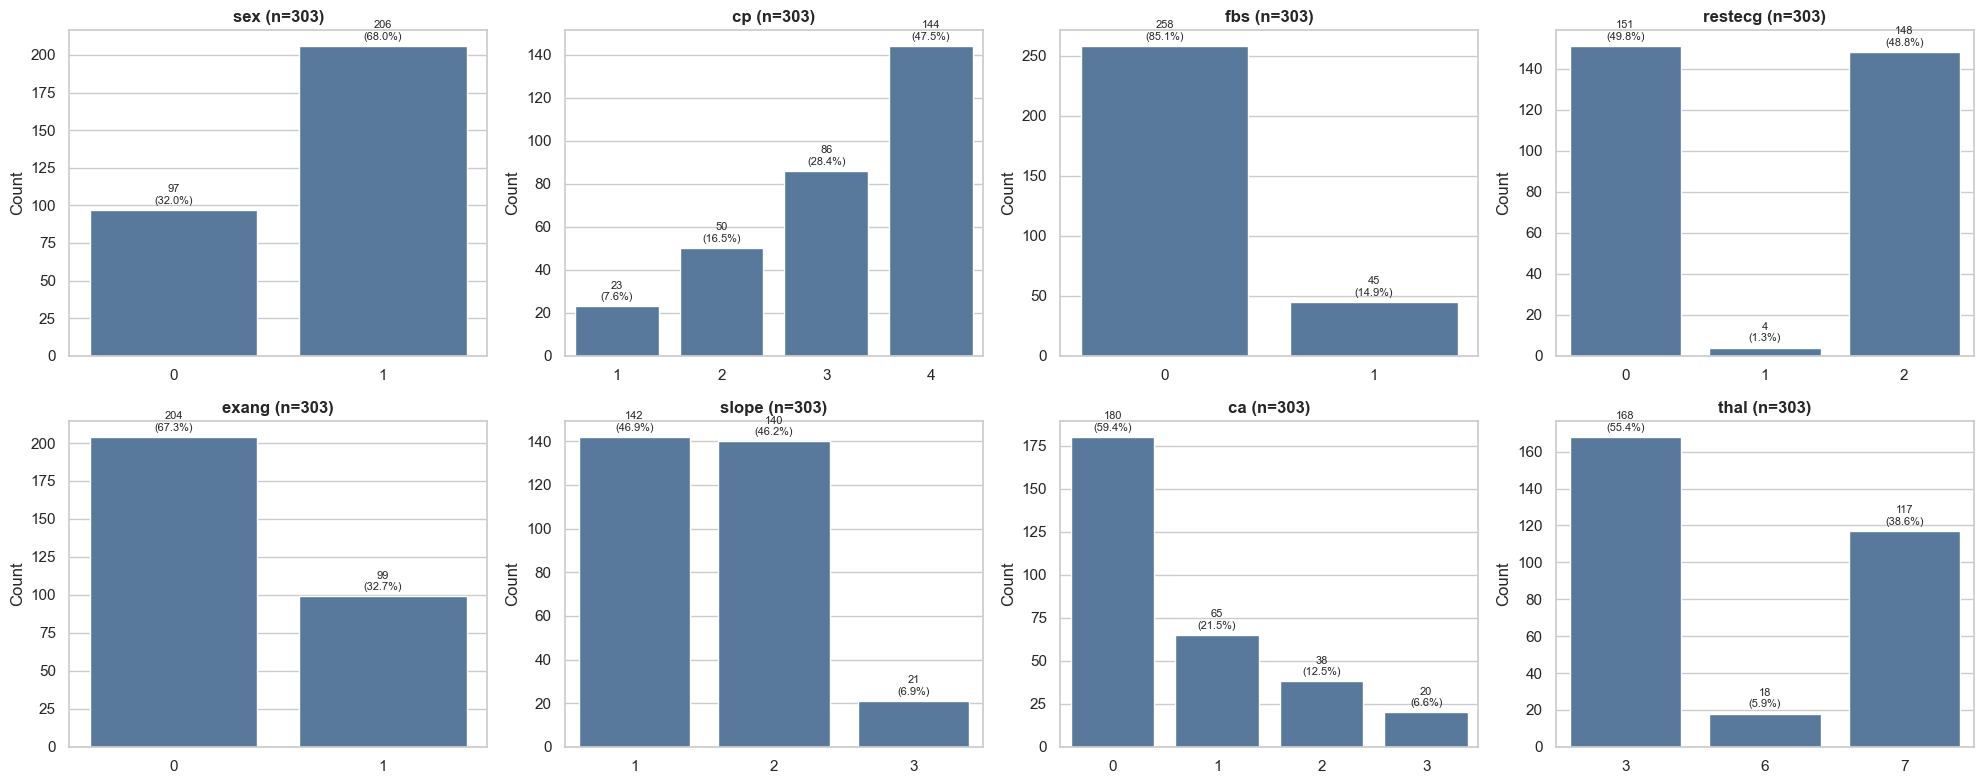

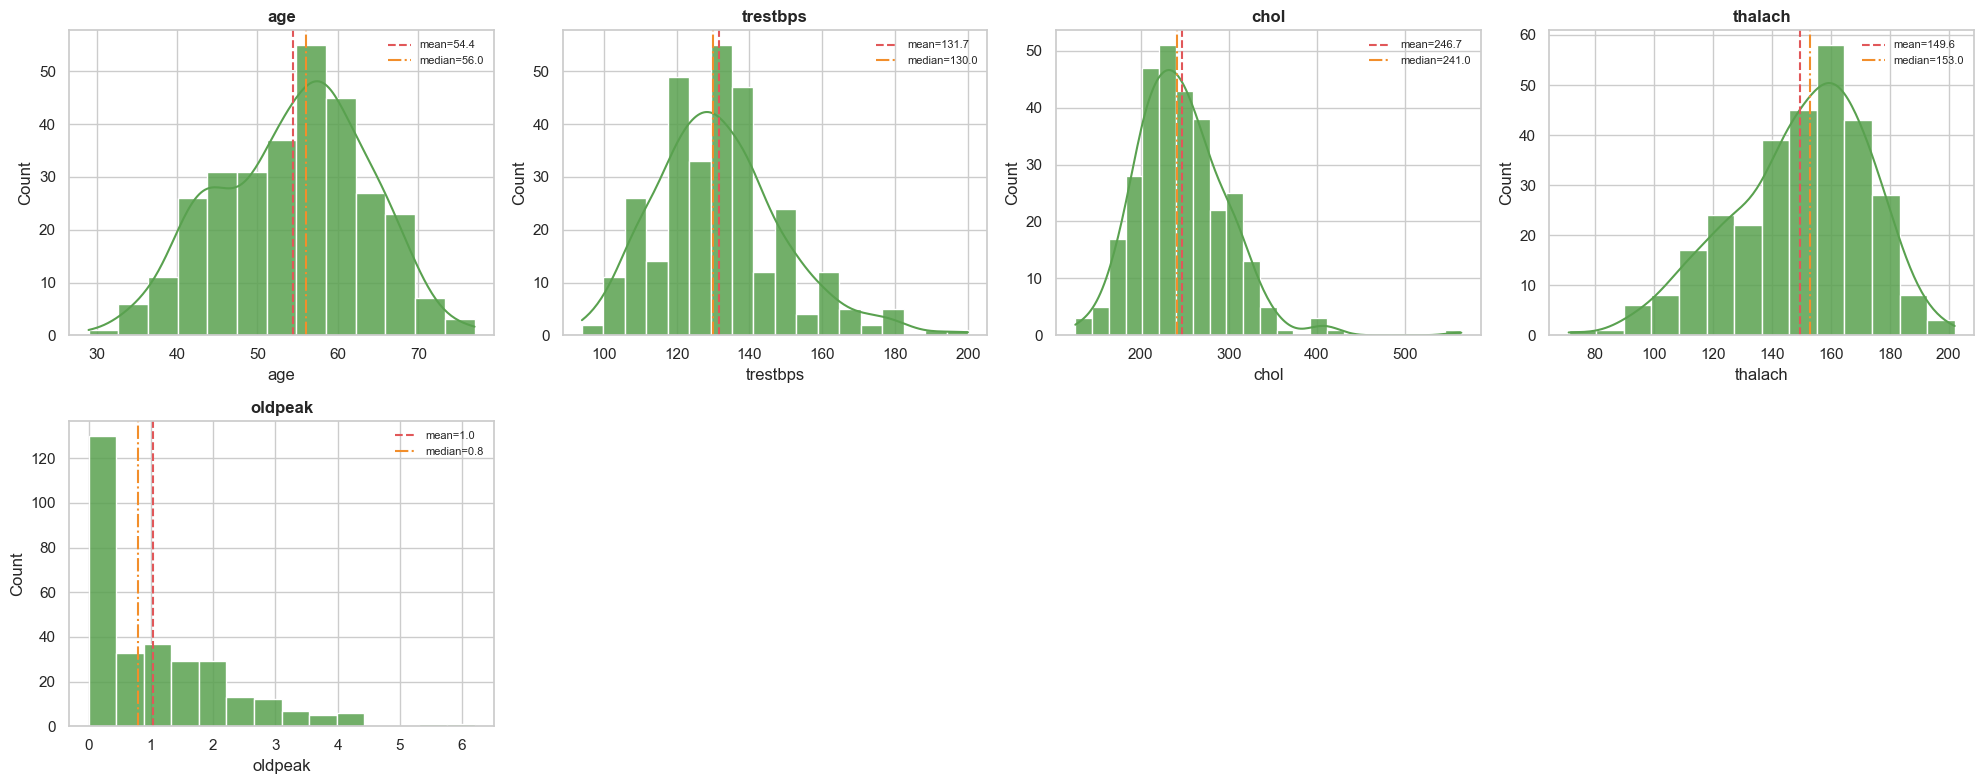

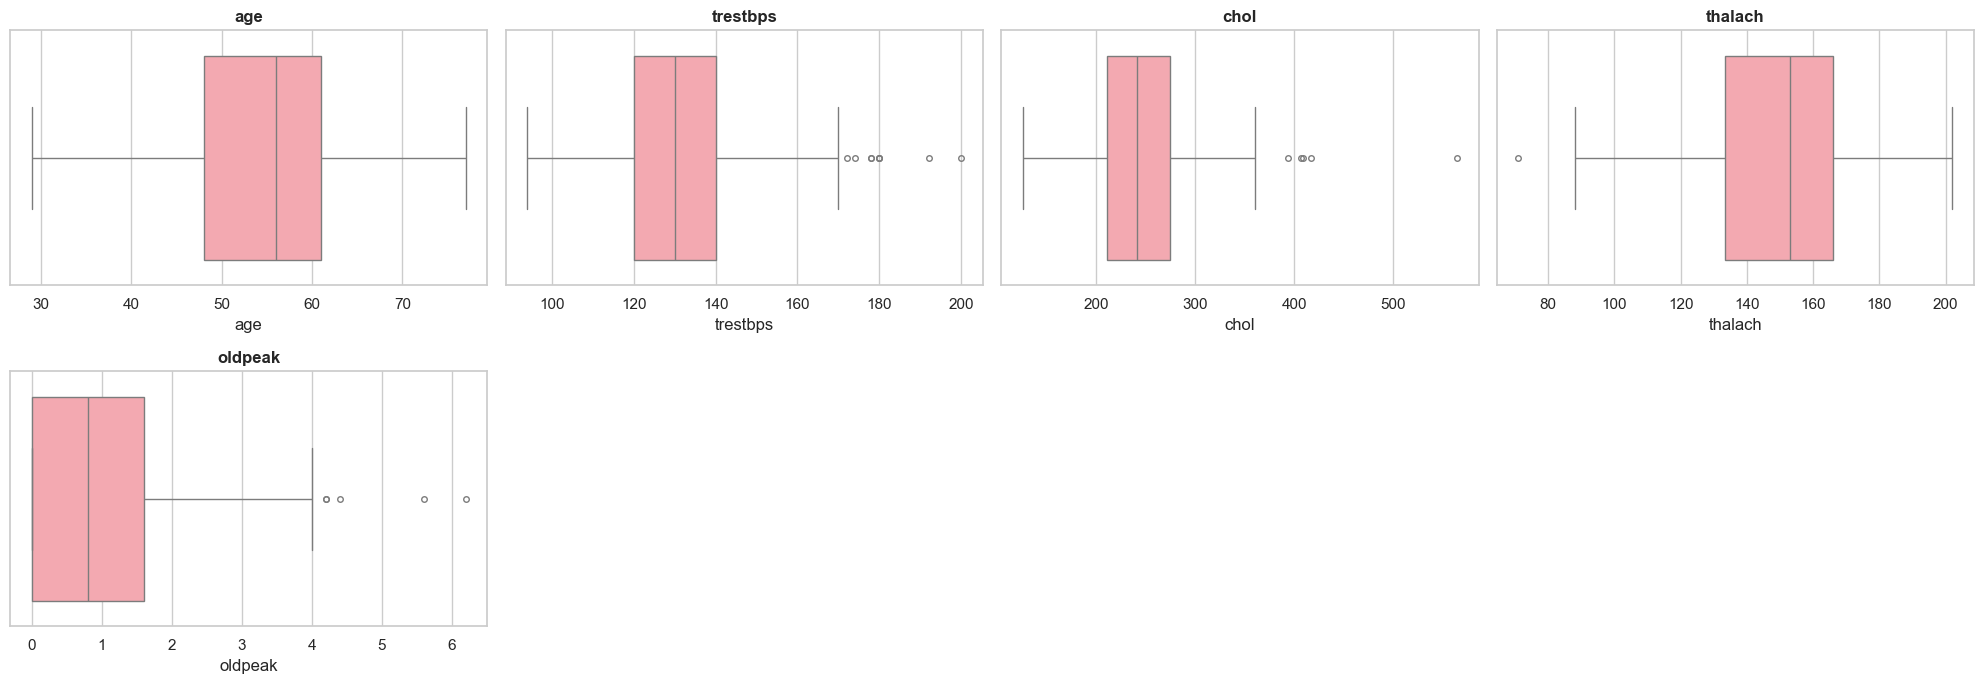

In [12]:
data = X_clean.copy()

# We identify the categorical and continuous variables based on the dataset
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
continuous_cols = [c for c in data.columns if c not in categorical_cols]

print("Categorical variables:", categorical_cols)
print("Continuous variables:", continuous_cols)

# Keep integrity of the categorical variables (ca/thal could be read as continuous but they are categorical)
for c in categorical_cols:
    data[c] = pd.to_numeric(data[c], errors="coerce").round().astype("Int64")

sns.set_theme(style="whitegrid", context="notebook")

# 1) For the categorical variables, we create count plots
n_cols = 4
n_rows = math.ceil(len(categorical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    order = sorted(data[col].dropna().unique().tolist())
    sns.countplot(x=col, data=data, order=order, ax=ax, color="#4C78A8")

    total = data[col].notna().sum()
    for p in ax.patches:
        h = int(p.get_height())
        ax.annotate(f"{h}\n({h/total:.1%})",
                    (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom", fontsize=8,
                    xytext=(0, 3), textcoords="offset points")

    ax.set_title(f"{col} (n={total})", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")


for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# 2) Continuous: histogram + KDE
n_rows = math.ceil(len(continuous_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(continuous_cols):
    ax = axes[i]
    use_kde = col != "oldpeak"  # oldpeak suele quedar mejor sin KDE
    sns.histplot(data[col], bins="fd", kde=use_kde, ax=ax,
                 color="#59A14F", edgecolor="white", alpha=0.85)

    mean_val = data[col].mean()
    med_val = data[col].median()
    ax.axvline(mean_val, color="#E15759", linestyle="--", linewidth=1.5, label=f"mean={mean_val:.1f}")
    ax.axvline(med_val, color="#F28E2B", linestyle="-.", linewidth=1.5, label=f"median={med_val:.1f}")

    ax.set_title(f"{col}", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend(frameon=False, fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# 3) Continuous: Boxplot
n_rows = math.ceil(len(continuous_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(continuous_cols):
    ax = axes[i]
    sns.boxplot(x=data[col], ax=ax, color="#FF9DA7", fliersize=4, linewidth=1)
    ax.set_title(f"{col}", fontweight="bold")
    ax.set_xlabel(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

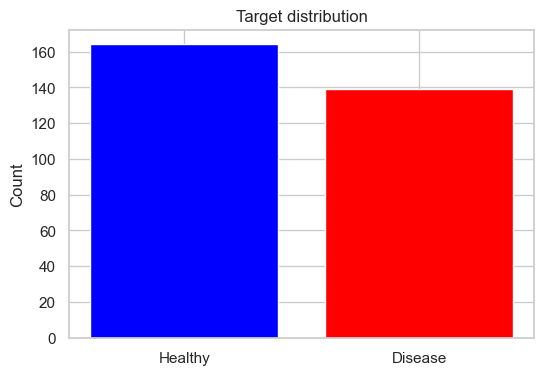

In [13]:
t = (y["num"] > 0).astype(int)   # 0 = healthy, 1 = disease
counts = t.value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Healthy", "Disease"], counts.values, color=["blue", "red"])
plt.ylabel("Count")
plt.title("Target distribution")
plt.show()

## Plotting correlation heatmap

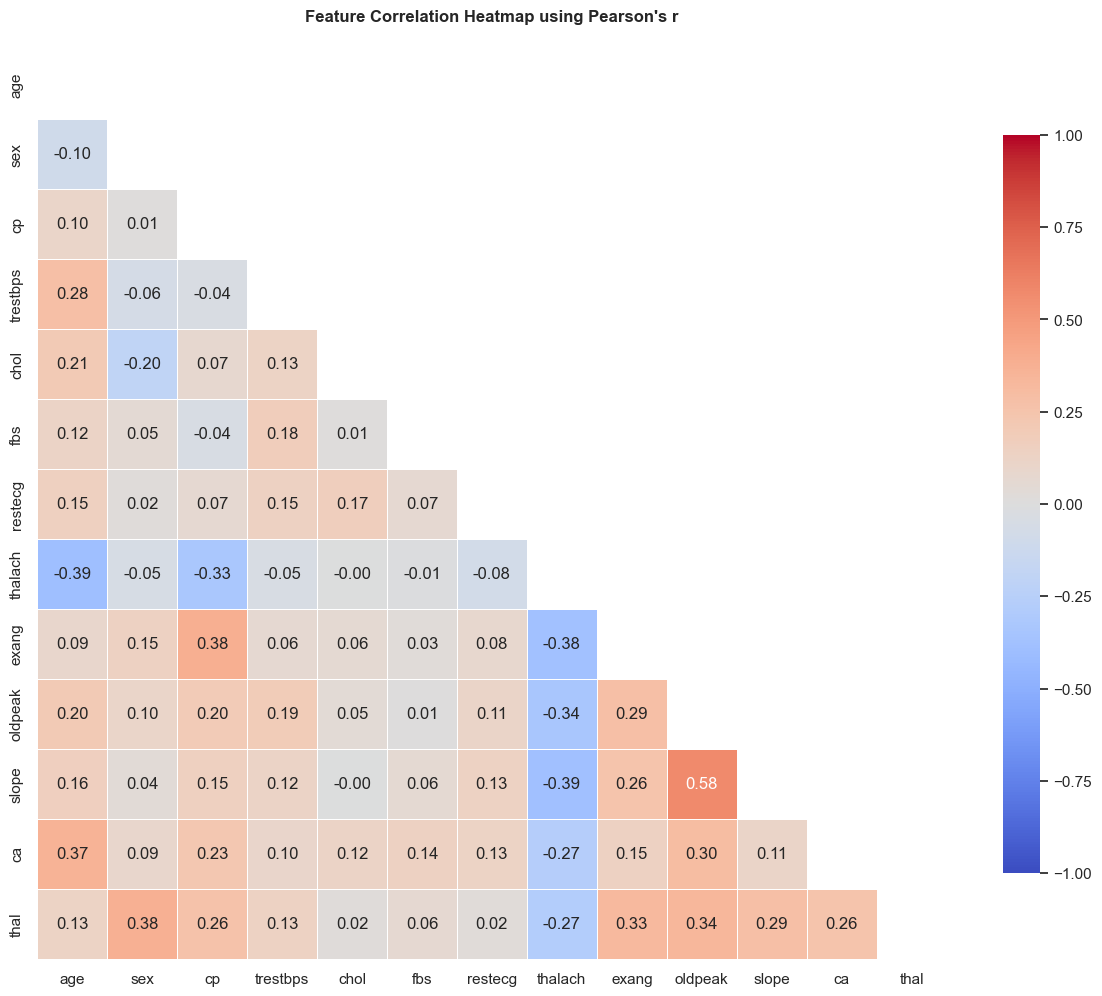

In [14]:
# We calculate the correlation matrix for the continuous variables (using Pearson correlation)
corr_pearson = data.corr(method="pearson")  

# Show only lower triangle (cleaner)
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_pearson,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Heatmap using Pearson's r", fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

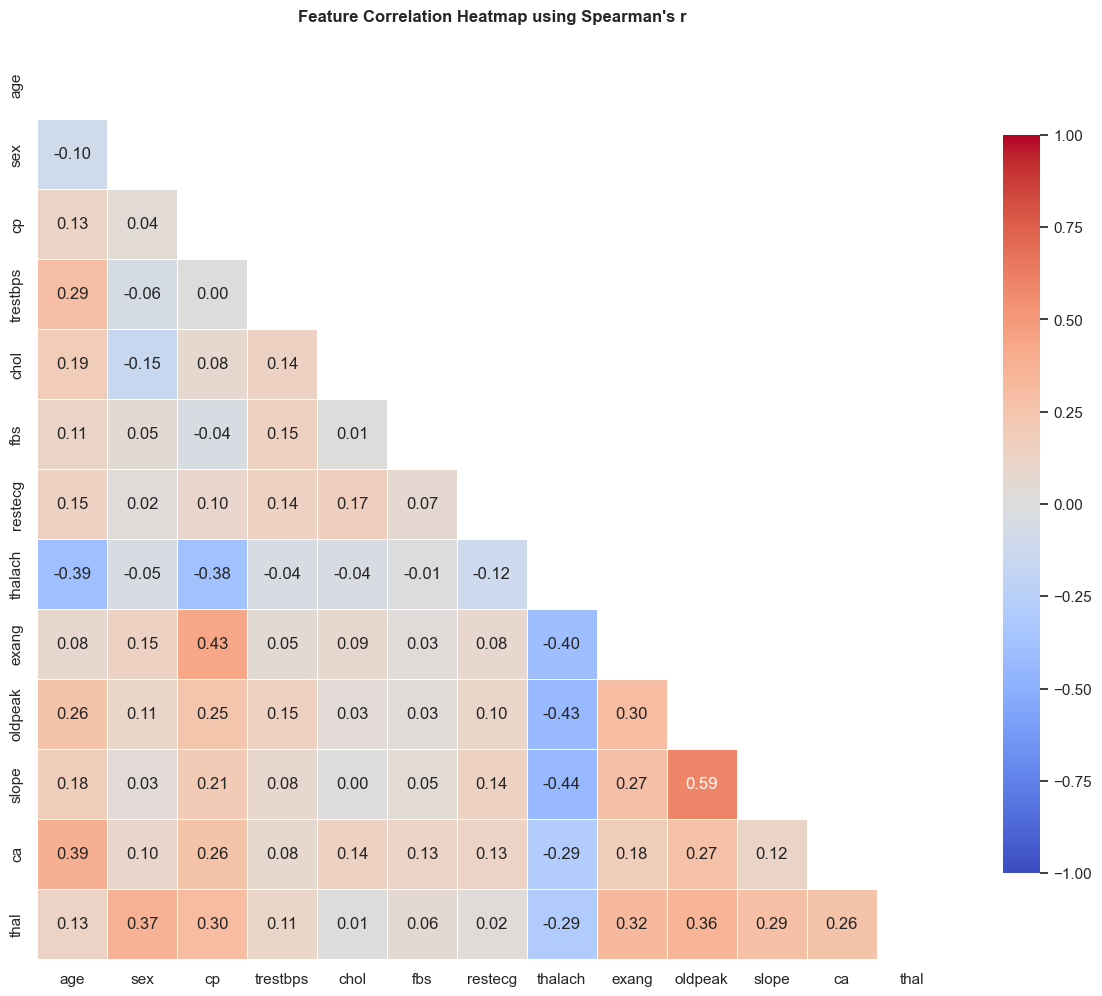

In [15]:
# We calculate the correlation matrix for the continuous variables (using Spearman correlation)
corr_spearman = data.corr(method="spearman")  

# Show only lower triangle (cleaner)
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_spearman,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Heatmap using Spearman's r", fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

We can observe that using Pearson's or Spearman's r leads to very similar feature correlation heatmaps; thus, we will discuss Pearson's approach. For simplicity, we only show the lower triangle to obtain a cleaner visualization and avoid redundancy.

Most features exhibit weak to moderate correlations (|r| < 0.4), which suggests limited collinearity within the dataset. However, we observe a stronger positive relationship (r ≈ 0.58) between the Slope of Peak ST Segment (slope) and ST depression (oldpeak). Both variables describe ST-segment dynamics recorded during ECG, therefore some physiological relationship is expected. Finally, Maximum Heart Rate Achieved (thalach) also shows moderately negative correlations, especially with age and slope, which is consistent with lower maximum heart rate in older or more symptomatic patients.

## Task 2: Preprocessing

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [17]:
# In this step we binarize the target column: we keep 0, but set anything >0 to 1
y = pd.DataFrame((y['num'] > 0).astype(int), columns=['num'])
print(y.head())

   num
0    0
1    1
2    1
3    0
4    0


### Encoding categorical features (One-hot encoding)

In [18]:
# We encode the features before applying standardization and PCA
data = X_clean.copy()

binary_cols = ["sex", "fbs", "exang"]  # keep as binary, convert to boolean
data[binary_cols] = data[binary_cols].eq(1)

# Target to boolean (works whether y is 0/1 or 0..4)
y_bool = (y["num"] if isinstance(y, pd.DataFrame) else y).gt(0)

nominal_cols = ["cp", "restecg", "slope", "ca", "thal"]  # one-hot encoding
# Drop first category to avoid multicollinearity
X_encoded = pd.get_dummies(data, columns=nominal_cols, drop_first=True, dtype=bool)

print("Original shape:", data.shape)
print("Encoded shape :", X_encoded.shape)
X_encoded.head()


Original shape: (303, 13)
Encoded shape : (303, 20)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_2,cp_3,cp_4,restecg_1,restecg_2,slope_2,slope_3,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0
0,63,True,145,233,True,150,False,2.3,False,False,False,False,True,False,True,False,False,False,True,False
1,67,True,160,286,False,108,True,1.5,False,False,True,False,True,True,False,False,False,True,False,False
2,67,True,120,229,False,129,True,2.6,False,False,True,False,True,True,False,False,True,False,False,True
3,37,True,130,250,False,187,False,3.5,False,True,False,False,False,False,True,False,False,False,False,False
4,41,False,130,204,False,172,False,1.4,True,False,False,False,True,False,False,False,False,False,False,False


As our machine learning models work with numerical inputs, we applied one-hot encoding to the dataset in order to binarize the nominal categorical variables (cp, restecg, slope, ca and thal). We decided not to use label encoding due to the possible introduction of an artificial numerical order between categories that may not have an ordinal relationship. However, variables that were already binary were kept unchanged. Moreover, we used drop_first=True to remove one category from each variable and avoid multicollinearity between the newly generated columns. The dropped category serves as the baseline. The result is a dataset of 303 samples and 20 columns, seven more than before.

### Standardization of our features

In [19]:
# X_encoded = output after get_dummies(...)
X_scaled = X_encoded.copy()

# Standardize only continuous columns
scaler = StandardScaler()
X_scaled[continuous_cols] = scaler.fit_transform(X_scaled[continuous_cols])

# Here we print the original encoded dataset and the standardized dataset, along with the columns that were standardized and those that were kept as binary 0/1.
print("Original columns:")
print(X_encoded)


Original columns:
     age    sex  trestbps  chol    fbs  thalach  exang  oldpeak   cp_2   cp_3  \
0     63   True       145   233   True      150  False      2.3  False  False   
1     67   True       160   286  False      108   True      1.5  False  False   
2     67   True       120   229  False      129   True      2.6  False  False   
3     37   True       130   250  False      187  False      3.5  False   True   
4     41  False       130   204  False      172  False      1.4   True  False   
..   ...    ...       ...   ...    ...      ...    ...      ...    ...    ...   
298   45   True       110   264  False      132  False      1.2  False  False   
299   68   True       144   193   True      141  False      3.4  False  False   
300   57   True       130   131  False      115   True      1.2  False  False   
301   57  False       130   236  False      174  False      0.0   True  False   
302   38   True       138   175  False      173  False      0.0  False   True   

      cp_

In [20]:
print("\nContinuous columns standardized:")
print(X_scaled)


Continuous columns standardized:
          age    sex  trestbps      chol    fbs   thalach  exang   oldpeak  \
0    0.948726   True  0.757525 -0.264900   True  0.017197  False  1.087338   
1    1.392002   True  1.611220  0.760415  False -1.821905   True  0.397182   
2    1.392002   True -0.665300 -0.342283  False -0.902354   True  1.346147   
3   -1.932564   True -0.096170  0.063974  False  1.637359  False  2.122573   
4   -1.489288  False -0.096170 -0.825922  False  0.980537  False  0.310912   
..        ...    ...       ...       ...    ...       ...    ...       ...   
298 -1.046013   True -1.234430  0.334813  False -0.770990  False  0.138373   
299  1.502821   True  0.700612 -1.038723   True -0.376896  False  2.036303   
300  0.283813   True -0.096170 -2.238149  False -1.515388   True  0.138373   
301  0.283813  False -0.096170 -0.206864  False  1.068113  False -0.896862   
302 -1.821745   True  0.359134 -1.386944  False  1.024325  False -0.896862   

      cp_2   cp_3   cp_4  res

In [21]:
# We also print the mean and standard deviation values used for scaling, which are stored in the scaler object after fitting. This gives us insight into how the continuous features were transformed.
print("\nScaler Values:")
print(f'\nMeans of each feature: {scaler.mean_}')
print(f'\nStandard deviations of each feature: {scaler.scale_}')

# We also check that the mean of the standardized columns is close to 0 and the standard deviation is close to 1, which confirms that the standardization was applied correctly.
print("\nMean of each column after scaling (should be close to 0):")
print(X_scaled[continuous_cols].mean())
print("\nStandard deviation of each column after scaling (should be close to 1):")
print(X_scaled[continuous_cols].std())


Scaler Values:

Means of each feature: [ 54.43894389 131.68976898 246.69306931 149.60726073   1.03960396]

Standard deviations of each feature: [ 9.02373483 17.57068124 51.69140647 22.83722455  1.15915747]

Mean of each column after scaling (should be close to 0):
age        -1.538923e-17
trestbps    4.259519e-16
chol        2.418308e-16
thalach    -1.179841e-16
oldpeak    -1.700144e-16
dtype: float64

Standard deviation of each column after scaling (should be close to 1):
age         1.001654
trestbps    1.001654
chol        1.001654
thalach     1.001654
oldpeak     1.001654
dtype: float64


Before performing PCA, it is necessary to scale our continuous data within a specific range. Since PCA is variance-based and clustering methods are sensitive to scale, standardization of feature values using the z-score is better suited for this task, as it ensures that variables are centered and have comparable variances. This prevents large numerical ranges from dominating our analyses.

### Step A — PCA:

In [22]:
X = X_scaled.copy()
X_mat = X.to_numpy(dtype=float)

### PCA using NumPy

d = X_mat.shape[0]  # number of samples

# Covariance matrix
S = (1/(d-1)) * X_mat.T @ X_mat
# eigenvalues are the variances of the principal components, eigenvectors are the directions of the principal components
[eigenvalues, eigenvectors] = np.linalg.eig(S) 
# We sort the eigenvalues in descending order and reorder the eigenvectors accordingly
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# We calculate the explained variance ratio for each principal component
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
print("Explained variance ratio of each principal component:")
print(explained_variance_ratio)

# Project the data onto the first 2 principal components
n = 2
W = eigenvectors[:, :n]  # projection matrix using the first n eigenvectors
X_pca_manual = X_mat @ W  # projected data in the PCA space
print("\nShape of PCA-transformed data (manual):", X_pca_manual.shape)

# Cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
print("\nCumulative explained variance ratio:")
print(cumulative_explained_variance)

# 85% of the variance is explained by the first 2 principal components
print("\nNumber of principal components needed to explain at least 85% of the variance:",
      np.argmax(cumulative_explained_variance >= 0.85) + 1)



Explained variance ratio of each principal component:
[0.25358308 0.17873346 0.12276921 0.09979647 0.08721514 0.05587056
 0.03554753 0.02754284 0.0234115  0.02082637 0.01843937 0.01647457
 0.01436077 0.01240881 0.01000482 0.00809157 0.0054718  0.00473195
 0.00340388 0.00131628]

Shape of PCA-transformed data (manual): (303, 2)

Cumulative explained variance ratio:
[0.25358308 0.43231654 0.55508575 0.65488222 0.74209736 0.79796793
 0.83351545 0.86105829 0.88446979 0.90529616 0.92373553 0.9402101
 0.95457088 0.96697969 0.97698451 0.98507609 0.99054789 0.99527984
 0.99868372 1.        ]

Number of principal components needed to explain at least 85% of the variance: 8


In [23]:
### 2) PCA con scikit-learn
pca = PCA(n_components=20)
X_pca_sklearn = pca.fit_transform(X)

#Explained variance ratio
print("Explained variance ratio of each principal component (sklearn):")
print(pca.explained_variance_ratio_)
print("\nShape of PCA-transformed data (sklearn):", X_pca_sklearn.shape)

# Cumulative explained variance
pca_cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
print("\nCumulative explained variance ratio:")
print(pca_cumulative_explained_variance)

# 85% of the variance is explained by the first 2 principal components
print("\nNumber of principal components needed to explain at least 85% of the variance:",
      np.argmax(pca_cumulative_explained_variance >= 0.85) + 1)

Explained variance ratio of each principal component (sklearn):
[0.26729601 0.15739247 0.1215409  0.10798331 0.06963363 0.04799615
 0.03486964 0.03261602 0.02825356 0.02517682 0.02235044 0.01881878
 0.01744497 0.01509823 0.01211682 0.00666522 0.0059575  0.00437641
 0.00281508 0.00159804]

Shape of PCA-transformed data (sklearn): (303, 20)

Cumulative explained variance ratio:
[0.26729601 0.42468848 0.54622937 0.65421268 0.72384632 0.77184246
 0.8067121  0.83932812 0.86758168 0.8927585  0.91510894 0.93392772
 0.95137269 0.96647092 0.97858775 0.98525297 0.99121047 0.99558688
 0.99840196 1.        ]

Number of principal components needed to explain at least 85% of the variance: 9


In Step A, we applied PCA using two different approaches: first, we performed a manual implementation with NumPy and matrix multiplication, and then using the scikit-learn library, in order to check that both methods lead to consistent results.

In the manual implementation, we calculated the covariance matrix and obtained the eigenvectors and eigenvalues through its decomposition. This allowed us to compute the proportion of explained variance for each principal component. From these results, we observed that in order to explain at least 85% of the variance, we needed the first 8 principal components [0.25358308 0.17873346 0.12276921 0.09979647 0.08721514 0.05587056 0.03554753 0.02754284]. On the other hand, using scikit-learn, the cumulative explained variance ratio showed that at least 9 principal components are required to explain the same percentage of variance [0.26729601 0.15739247 0.1215409 0.10798331 0.06963363 0.04799615 0.03486964 0.03261602 0.02825356]. Even though both methods present a slight difference in values, they lead to a similar conclusion: the dataset requires several dimensions to preserve most of its information.

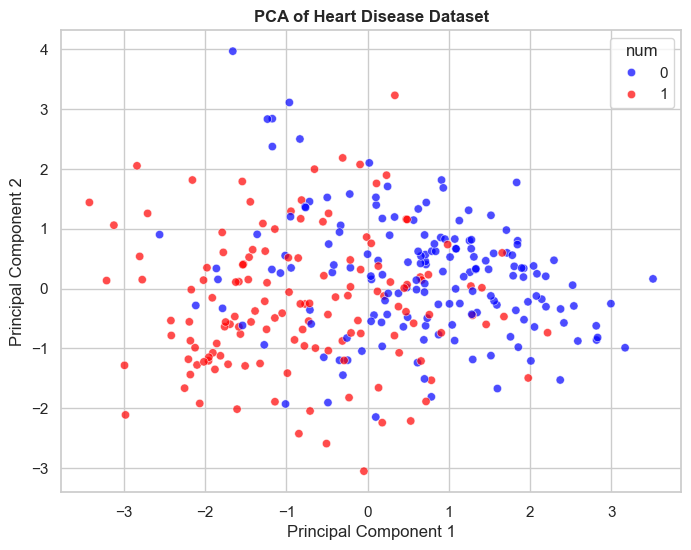

In [24]:
# Plot PCA results
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_sklearn[:, 0], y=X_pca_sklearn[:, 1], hue=y['num'], palette=["blue", "red"], alpha=0.7)
sns.set_theme(style="whitegrid", context="notebook")
plt.title("PCA of Heart Disease Dataset", fontweight="bold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

The projection of the data onto the first two principal components allows us to visualize the general structure of the dataset. However, as we can see when using the labels, it does not show a clear separation between the two classes. We can observe some local tendencies: blue dots (healthy) seem to be slightly concentrated on the right side of the plot, while red dots (disease) are more distributed on the left side. However, there is a clear overlap between both groups, which, according to the variance ratio of the first two principal components [0.26729601 0.15739247], confirms that they are not easily separable. Therefore, PCA can be a useful tool for visualization, but two-dimensional projections will not clearly differentiate the observations in a complex dataset.

### Step B — Feature selection:

In [25]:
X_input = X_encoded.copy()   # features
y_input = y_bool.copy()      # boolean target (True/False)

# 1) Split BEFORE the feature selection
X_train, X_test, y_train, y_test = train_test_split(
    X_input,
    y_input,
    test_size=0.20,
    random_state=42,
    stratify=y_input
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (242, 20) Test: (61, 20)


### Fitler method

In [26]:
# Method: Mutual Information
# Type: Filter method
# Nature: Univariate
# Data type: numerical / categorical features with categorical target

k = 8  # number of features to keep

filter_selector = SelectKBest(score_func=mutual_info_classif, k=k)
filter_selector.fit(X_train, y_train)

filter_scores = pd.Series(
    filter_selector.scores_,
    index=X_train.columns
).sort_values(ascending=False)

selected_filter = filter_scores.head(k).index.tolist()

print("Top features (Filter - Mutual Information):")
display(filter_scores.head(k))

Top features (Filter - Mutual Information):


thal_7.0    0.161679
exang       0.114676
ca_3.0      0.093232
cp_4        0.092248
fbs         0.085782
thalach     0.083713
slope_2     0.069155
ca_1.0      0.068472
dtype: float64

### Wrapper method

In [27]:
# Method: Recursive Feature Elimination (RFE)
# Type: Wrapper
# Nature: Multivariate

model = LogisticRegression(max_iter=10000, random_state=42)

wrapper_selector = RFE(
    estimator=model,
    n_features_to_select=k
)

wrapper_selector.fit(X_train, y_train)

selected_wrapper = X_train.columns[wrapper_selector.support_].tolist()

print("Selected features (Wrapper - RFE):")
print(selected_wrapper)

Selected features (Wrapper - RFE):
['sex', 'exang', 'cp_4', 'slope_2', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_7.0']


### Overlap

In [28]:
overlap = sorted(set(selected_filter).intersection(selected_wrapper))

print("Filter method features:")
print(selected_filter)

print("\nWrapper method features:")
print(selected_wrapper)

print("\nOverlap between methods:")
print(overlap)

Filter method features:
['thal_7.0', 'exang', 'ca_3.0', 'cp_4', 'fbs', 'thalach', 'slope_2', 'ca_1.0']

Wrapper method features:
['sex', 'exang', 'cp_4', 'slope_2', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_7.0']

Overlap between methods:
['ca_1.0', 'ca_3.0', 'cp_4', 'exang', 'slope_2', 'thal_7.0']


### Comparison with PCA and final feature subset for clustering

In [29]:
# PCA feature importance based on loadings and explained variance ratio
pc_names = [f"PC{i+1}" for i in range(pca.n_components_)]
loadings = pd.DataFrame(pca.components_.T, index=X_train.columns, columns=pc_names)

weights = pd.Series(pca.explained_variance_ratio_, index=pc_names)
pca_importance = loadings.abs().mul(weights, axis=1).sum(axis=1).sort_values(ascending=False)

# Top features for PCA
k = max(len(selected_filter), len(selected_wrapper))
selected_pca = pca_importance.head(k).index.tolist()

print("Top features por PCA:")
print(selected_pca)

# Comparison of the three methods
comparison = pd.DataFrame({
    "PCA_importance": pca_importance,
    "in_filter": [f in selected_filter for f in pca_importance.index],
    "in_wrapper": [f in selected_wrapper for f in pca_importance.index],
    "in_PCA_top": [f in selected_pca for f in pca_importance.index],
})

# Count how many methods selected each feature
comparison["n_methods"] = (
    comparison[["in_filter", "in_wrapper", "in_PCA_top"]]
    .sum(axis=1)
)

# Feature present in at least two methods
comparison["in_at_least_one"] = comparison["n_methods"] >= 1

comparison = comparison.sort_values("PCA_importance", ascending=False)

display(comparison.head(20))

# Extract features selected by at least two methods
features_one_methods = comparison[comparison["in_at_least_one"]].index.tolist()
n_one_methods = len(features_one_methods)

print("\nFeatures present in at least two methods:", features_one_methods)
print("Number of features present in at least two methods:", n_one_methods)

Top features por PCA:
['thalach', 'oldpeak', 'age', 'trestbps', 'chol', 'cp_4', 'exang', 'thal_7.0']


,PCA_importance,in_filter,in_wrapper,in_PCA_top,n_methods,in_at_least_one
thalach,0.325396,True,False,True,2,True
oldpeak,0.315603,False,False,True,1,True
age,0.304566,False,False,True,1,True
trestbps,0.295121,False,False,True,1,True
chol,0.293689,False,False,True,1,True
cp_4,0.152736,True,True,True,3,True
exang,0.139056,True,True,True,3,True
thal_7.0,0.135734,True,True,True,3,True
slope_2,0.131376,True,True,False,2,True
cp_3,0.110648,False,False,False,0,False



Features present in at least two methods: ['thalach', 'oldpeak', 'age', 'trestbps', 'chol', 'cp_4', 'exang', 'thal_7.0', 'slope_2', 'sex', 'ca_1.0', 'ca_2.0', 'fbs', 'ca_3.0']
Number of features present in at least two methods: 14


The training and test set split were performed as (80 % - 20%). To perform variable selection, we applied two different approaches to the training set: a filter method and a wrapper method. First, we used Mutual Information as a univariate filtering technique to measure the dependency between each variable and the target. This method is model-agnostic and allows us to identify which variables carry more information individually, thus producing a ranking (k = 8) of feature relevance. Afterwards, we applied a wrapper method through Recursive Feature Elimination (RFE) with a logistic regression model, which evaluates the contribution of variables in a multivariate way by considering their combined effect on the model. Finally, we compared these results with the contribution of each variable to the PCA by computing the weighted loadings, obtained by multiplying the absolute loadings by the explained variance ratio of each principal component.

Given that the categorical variables were encoded through one-hot encoding, the generated columns were interpreted as corresponding groups of the same original variable rather than as independent variables. For this reason, the final selection was performed considering the overall relevance of each original variable. We prioritized those variables that appeared in at least two methods and that showed the greatest contribution to the PCA structure. Following this criterion, we retained the variables related to maximum heart rate achieved (thalach), ST depression (oldpeak), chest pain type (cp), exercise-induced angina (exang), slope of the peak ST segment (slope), cholesterol (chol), resting blood pressure (trestbps), age, and the thalassemia indicator (thal). On the other hand, resting ECG results (restecg), fasting blood sugar (fbs), and major vessels (ca) were discarded because they were not selected by any of the methods or showed low importance in the selection criteria, with a limited contribution to the PCA structure. Therefore, we end up with 13 columns.


In [30]:
selected_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "exang",
    "cp_2", "cp_3", "cp_4",
    "slope_2", "slope_3",
    "thal_6.0", "thal_7.0"
]

not_selected_features = [
    "restecg_1", "restecg_2",
    "sex",
    "fbs",
    "ca.1", "ca.2", "ca.3"
]

# Apply selection to train and test sets
X_train_selected = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

print("Train shape after feature selection:", X_train_selected.shape)
print("Test shape after feature selection:", X_test_selected.shape)

Train shape after feature selection: (242, 13)
Test shape after feature selection: (61, 13)


## Task 3: K-Means

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In order to proceed with the clustering task, the preprocessed dataset with standardized and normalized variables, as well as selected features, was used.

In [32]:
# X is already scaled and preprocessed
print(X.shape) 
X_selected = X[selected_features].copy() #feature selection
print(X_selected.shape) 
X_selected.head()

(303, 20)
(303, 13)


,age,trestbps,chol,thalach,oldpeak,exang,cp_2,cp_3,cp_4,slope_2,slope_3,thal_6.0,thal_7.0
0,0.948726,0.757525,-0.264900,0.017197,1.087338,False,False,False,False,False,True,True,False
1,1.392002,1.611220,0.760415,-1.821905,0.397182,True,False,False,True,True,False,False,False
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147,True,False,False,True,True,False,False,True
3,-1.932564,-0.096170,0.063974,1.637359,2.122573,False,False,True,False,False,True,False,False
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912,False,True,False,False,False,False,False,False


Apply K-Means for values of k from 2 to 10.

In [33]:
# K-Means Algorithm -- Implementation with Scikit-learn
inertia_avg = []
silhouette_avg = []

for k in range(2, 11):
    inertia_list = []
    silhouette_list = []
    
    # Testing for several seeds provides robustness across different centroids initializations. 
    for seed in [0, 42, 88]:
        # However, n_init=20 already handles random initialization internally and k-means++ where the subsequent 
        #centroid is chosen based on its squared distance from the already chosen centroids. 
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=seed)
        kmeans.fit(X_selected)
        inertia_list.append(kmeans.inertia_)
        silhouette_list.append(silhouette_score(X_selected, kmeans.labels_))
    
    inertia_avg.append(np.mean(inertia_list))
    silhouette_avg.append(np.mean(silhouette_list))
    

Compute the Elbow Method and the Silhouette Score for each k and plot it  to identify the optimal k.

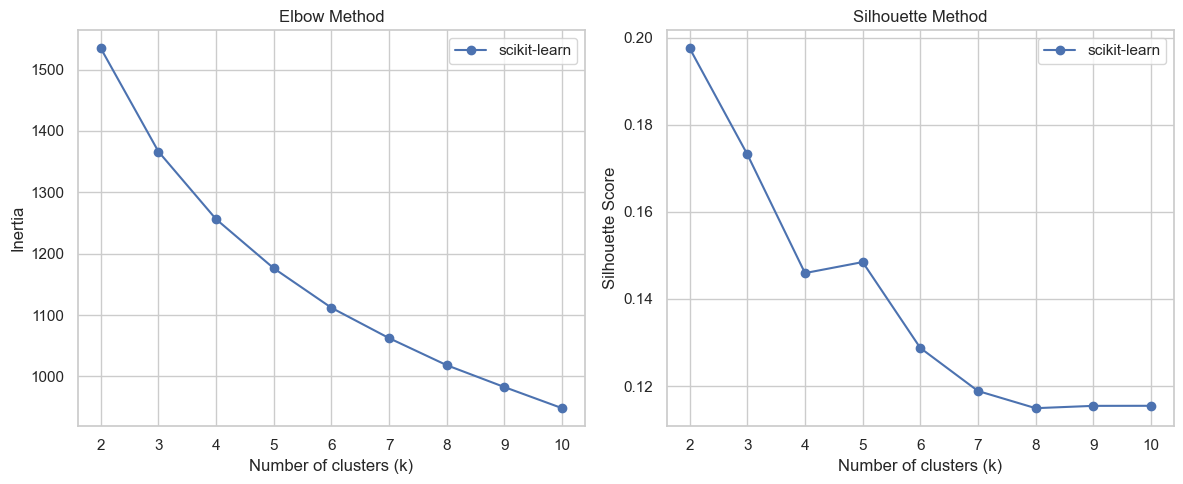

In [34]:
k_values = range(2, 11)
plt.figure(figsize=(12, 5))

# Elbow Method plot (Inertia)
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia_avg, marker='o', label='scikit-learn')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.legend()

# Silhouette plot
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_avg, marker='o', label='scikit-learn')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


The **Elbow Method** analyses how the Sum of Squared Errors (SSE) changes with the number of clusters and is a widely used techique for determining the optimal number of cluster (k). In general, adding more clusters reduces the SSE, since more centroids are placed. However, there is a value of k where adding additional clusters does not significally reduce the SEE. This behavoir forms a characteristic "elbow" shape in the SEE curve, and identifing the k value at this elbow point provides a good estimate for the optimal number of clusters. In this case, the SSE curve does not draw a clear elbow shape, making difficult to determine the precise optimal value of k. 

The **Silhouette Method** can be used to support the Elbow selection, it evaluated the compactness and separation of clusters. Higher values of the Silhouette coefficient indicate better defined and separated clusters. 

Based on both plots, the optimal k chosed was 5. This value corresponds to a point on the SSE curve (even though the elbow is not very pronounced) and also has a slightly higher Silhouette coefficient compared to the neighboring k values. However, the Silhouette score of ~0.15 suggests that the cluster structure may be weak or possibly artificial. 




In [35]:
# Fit final K-Means on the full preprocessed (scaled) dataset
optimal_k = 5  # Chosen k = 5
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=20, random_state=88)
final_kmeans.fit(X_selected)
full_labels = final_kmeans.labels_

Visualise the cluster assignments by projecting the data into PCA space (2D). Report and
interpret the cluster centres directly in the original feature space, which features are highest
or lowest for each group?

c:\Users\maria\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


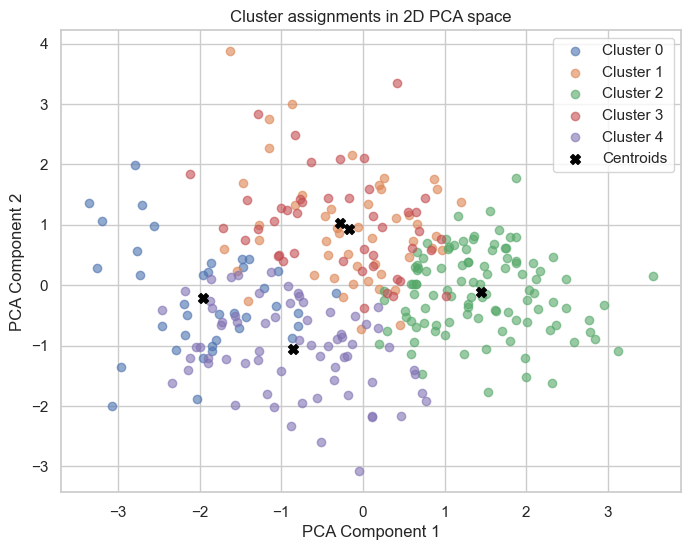

In [36]:
#PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected)

#Plot clusters
plt.figure(figsize=(8,6))
for cluster in np.unique(full_labels):
    cluster_points = X_pca[full_labels == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster}', alpha=0.6)

#Plot cluster centroids in PCA space
centroids_pca = pca.transform(final_kmeans.cluster_centers_)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=50, c='black', marker='X', label='Centroids')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Cluster assignments in 2D PCA space')
plt.legend()
plt.grid(True)
plt.show()

PCA allows us to visually inspect the clusters obtained from the K_Means algorithm. Looking at the figure above, the overlap between clusters suggests that the separation is weak, specially among clusters 1 and 3 which show a high degree of superposition. 

Cluster Interpretation and Characterization

In [37]:
# Add the Cluster 
X_full_df = X_selected.copy()  # if X_full is a DataFrame
X_full_df['K-means Cluster'] = full_labels
X_full_df.head()

,age,trestbps,chol,thalach,oldpeak,exang,cp_2,cp_3,cp_4,slope_2,slope_3,thal_6.0,thal_7.0,K-means Cluster
0,0.948726,0.757525,-0.264900,0.017197,1.087338,False,False,False,False,False,True,True,False,0
1,1.392002,1.611220,0.760415,-1.821905,0.397182,True,False,False,True,True,False,False,False,0
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147,True,False,False,True,True,False,False,True,4
3,-1.932564,-0.096170,0.063974,1.637359,2.122573,False,False,True,False,False,True,False,False,2
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912,False,True,False,False,False,False,False,False,2


In [38]:
cluster_summary = X_full_df.groupby('K-means Cluster').agg(['mean', 'std', 'min', 'max'])
cluster_summary = X_full_df.groupby('K-means Cluster').agg(['mean'])
print(cluster_summary)

                      age  trestbps      chol   thalach   oldpeak     exang  \
                     mean      mean      mean      mean      mean      mean   
K-means Cluster                                                               
0                0.628250  0.814438  0.129854 -0.575718  1.884749  0.486486   
1                0.467004 -0.251809  1.225893  0.229883 -0.183817  0.306122   
2               -0.922529 -0.426265 -0.334913  0.740327 -0.550962  0.142857   
3                0.694347  1.254220 -0.104420  0.336652 -0.445907  0.227273   
4                0.296851 -0.415050 -0.369310 -1.213379  0.246210  0.602941   

                     cp_2      cp_3      cp_4   slope_2   slope_3  thal_6.0  \
                     mean      mean      mean      mean      mean      mean   
K-means Cluster                                                               
0                0.000000  0.135135  0.756757  0.621622  0.297297  0.135135   
1                0.183673  0.387755  0.408163  0.44

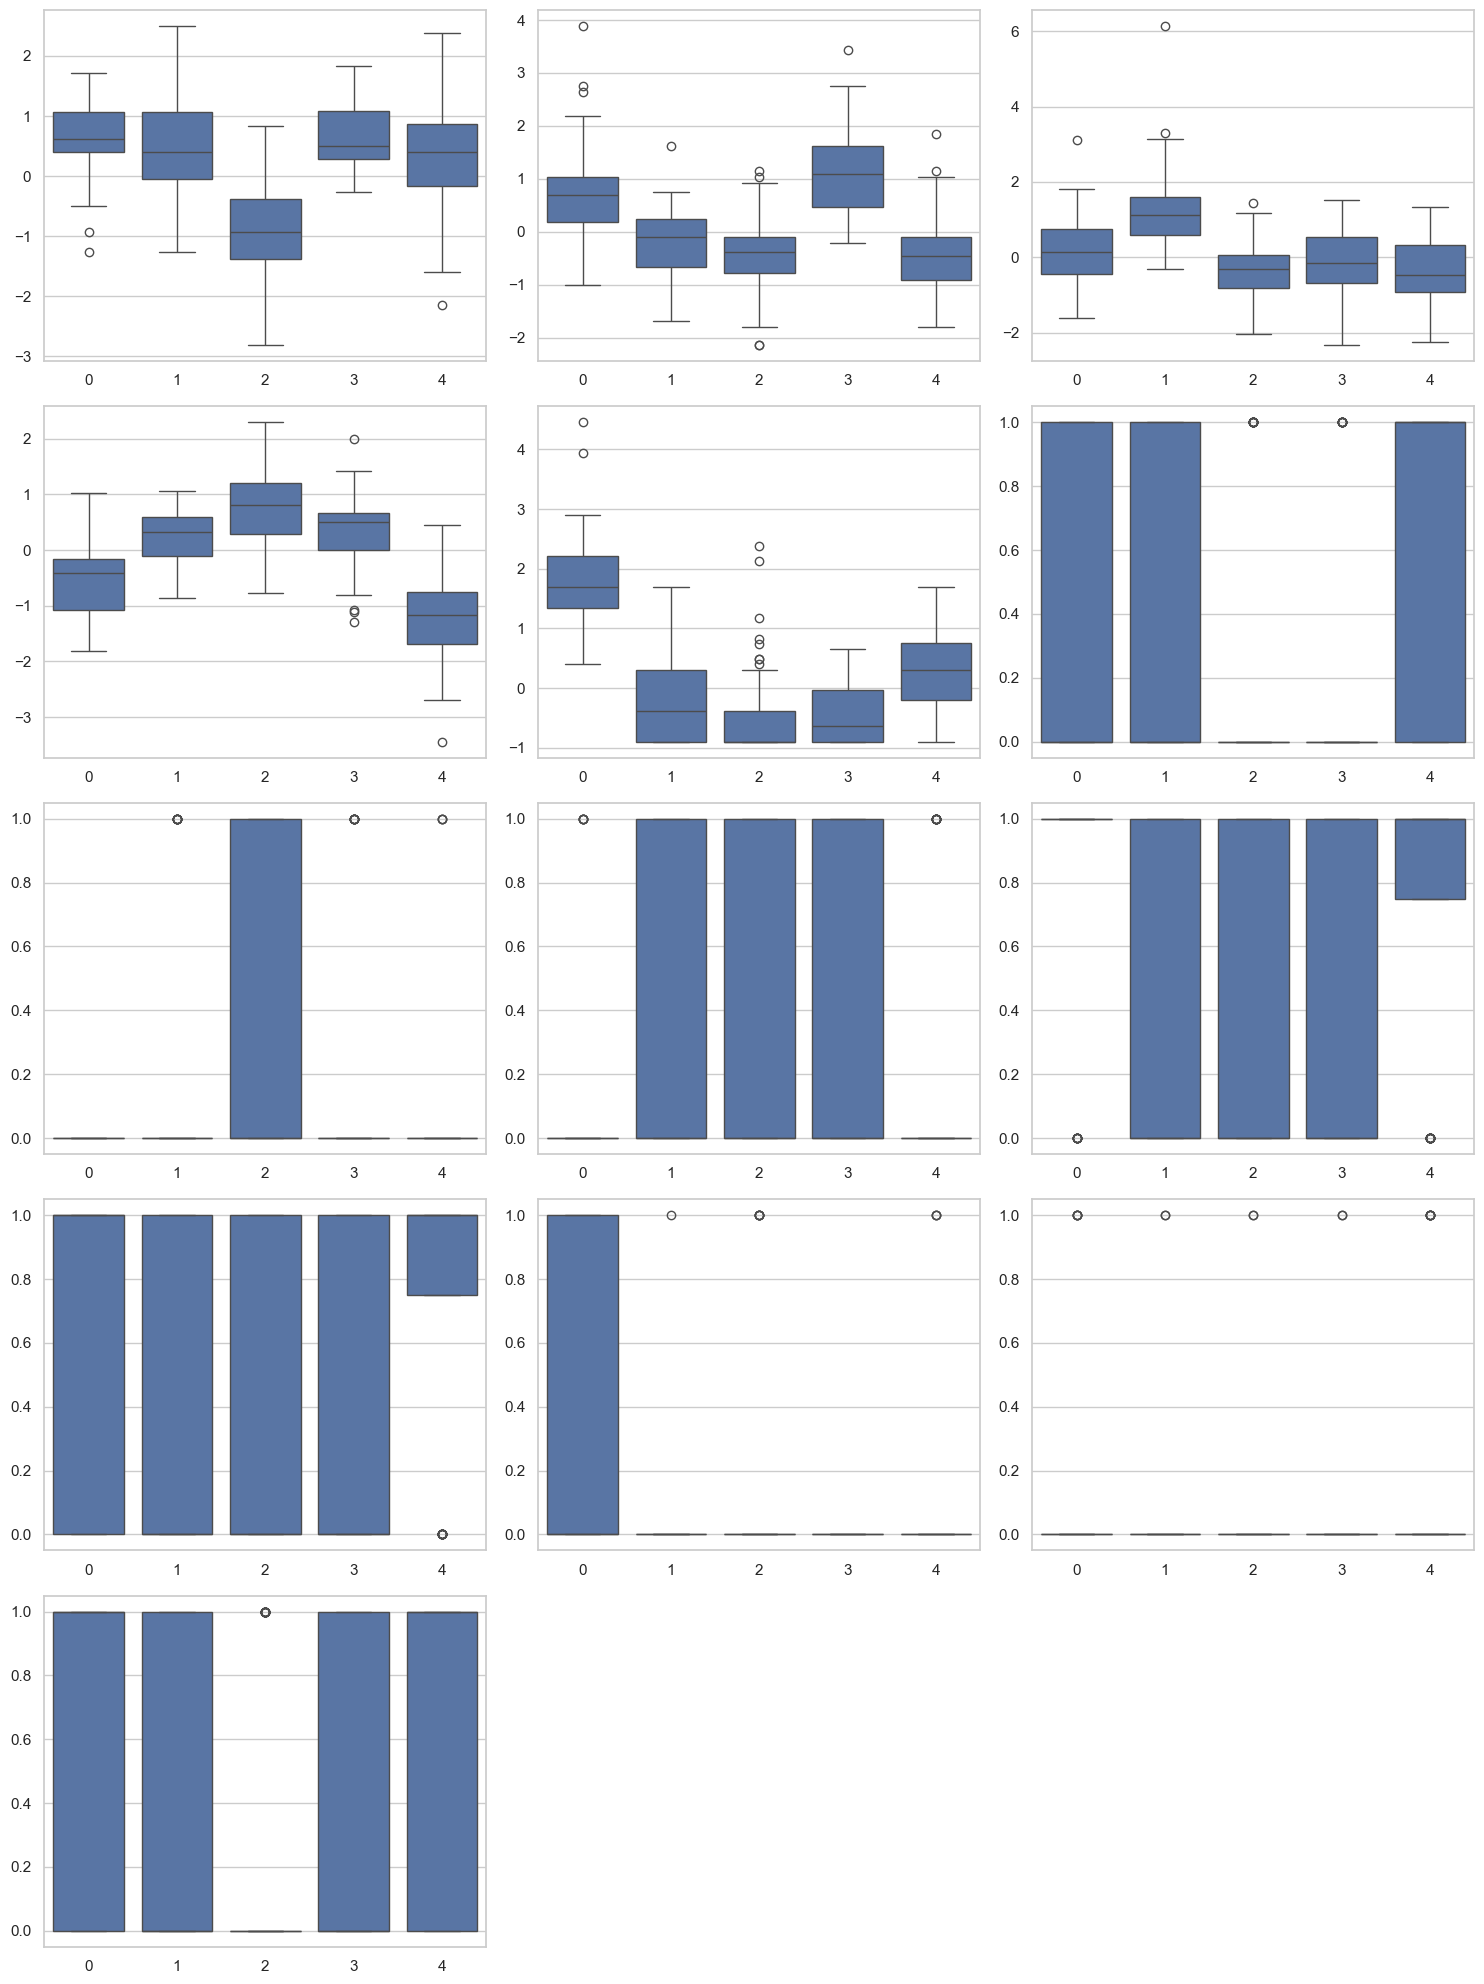

In [39]:
n_features = len(X_selected.columns)
n_cols = 3  # number of columns in the subplot grid
n_rows = (n_features + n_cols - 1) // n_cols  # compute number of rows needed

X_full_df_plot = X_full_df.copy()
bool_cols = X_full_df_plot.select_dtypes(include="bool").columns
X_full_df_plot[bool_cols] = X_full_df_plot[bool_cols].astype(int)

plt.figure(figsize=(5*n_cols, 4*n_rows))  # adjust figure size

for i, col in enumerate(X_selected.columns):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(x='K-means Cluster', y=col, data=X_full_df_plot)
    plt.xlabel('')  # optional, cleaner labels
    plt.ylabel('')  # optional, cleaner labels

plt.tight_layout()
plt.show()

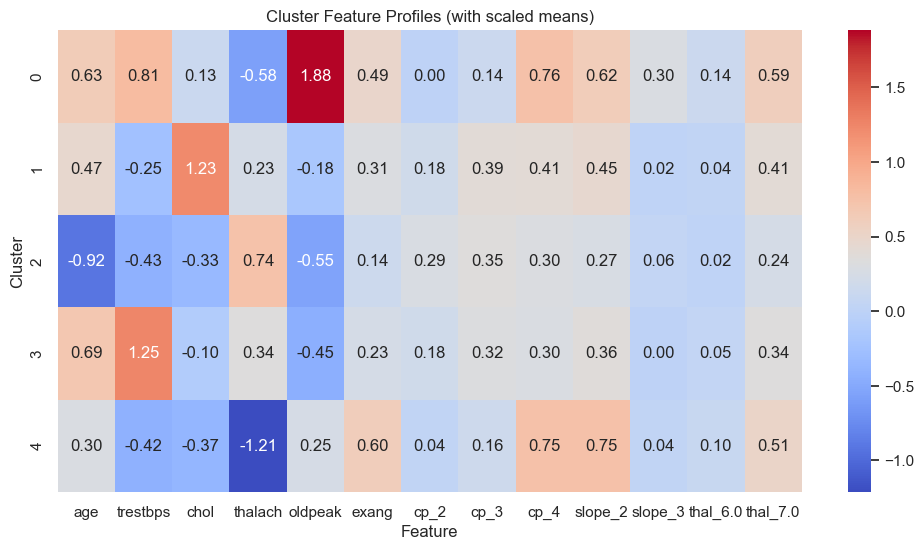

In [40]:
# Compute mean of each feature per cluster
kmeans_means = X_full_df.groupby('K-means Cluster').mean()

plt.figure(figsize=(12,6))
sns.heatmap(kmeans_means, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cluster Feature Profiles (with scaled means)")
plt.ylabel("Cluster")
plt.xlabel("Feature")
plt.show()

Finally, to characterize each of the obtained clusters, summary statistics for each feature within each cluster were computed. 

The dataset was standardize in previous tasks, so the mean values represent variations from the dataset average. Therefore, positive values indicate that a feature is above the average for a given cluster, while negative values indicate that it is below the average. For categorical variables, the mean corresponds to the proportion of samples belonging to that category within each cluster.

Despite the low cluster separation in the PCA plot, the cluster feature profile reveal some characteristic patterns across the five obtained clusters. 

- **Cluster 0** is characterized by the lower age (mean = -1.00), low ST depression (oldpeak = -0.57) and the highest maximum heart rate (thalach = 0.77). These features suggest that this cluster may correspond to a younger and healthier group with low cardiovascular risk.

- **Cluster 1** is characterized by the highest age (mean = 0.72) and elevated blood pressure (trestbps = 1.19).The remaining features are close to average values, suggesting that this cluster represents an older population with moderate cardiovascular risk.

- **Cluster 2** is the group with the highest cardiovascular risk. It is characterized by a very low maximum heart rate (thalach = -1.02) and high ST depression (oldpeak = 1.43). It also has a high proportion of exercise induced angina (0.61) and severe chest pain (cp_4 = 0.89).

- **Cluster 3** is characterised by having higher cholesterol levels (chol = 1.56), while other features are closer to average values. Clusters 1 and 3 both present feature values near the dataset mean for most variables, which explains the overlap observed between them in the PCA visualization.

- **Cluster 4** shows a mixed profile, with lower blood pressure (trestbps = -0.70) and cholesterol (chol = -0.47) means, but at the same time a high proportion of severe chest pain (cp_4 = 0.60) and abnormal thalassemia (0.46). This combination of favorable and adverse characteristics makes the risk profile of this cluster more difficult to interpret.

Overall, the cluster feature show characteristic differences across clusters, specially in terms of age, blood plessure, cholesterol and cardiovascular function indicators. However, considering the overlap observed in the PCA visualization, we should not consider these different clusters as strictly separated groups of patients. 


## Task 4: GMM

In [41]:
from sklearn.mixture import GaussianMixture

In [42]:
gmm_models = {}

for n in range(2, 11):
    gmm = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42
    )
    gmm.fit(X_selected)
    gmm_models[n] = gmm
    print(f"n_components={n} — BIC: {gmm.bic(X_selected):.2f} | AIC: {gmm.aic(X_selected):.2f}")



n_components=2 — BIC: 918.53 | AIC: 142.36
n_components=3 — BIC: -2869.11 | AIC: -4035.22
n_components=4 — BIC: -2231.48 | AIC: -3787.53
n_components=5 — BIC: -3457.66 | AIC: -5403.65
n_components=6 — BIC: -5252.01 | AIC: -7587.95
n_components=7 — BIC: -3645.29 | AIC: -6371.17
n_components=8 — BIC: -2822.42 | AIC: -5938.25
n_components=9 — BIC: -924.50 | AIC: -4430.26
n_components=10 — BIC: -4127.59 | AIC: -8023.29


In [43]:
# Accessing model with n=3
model_3 = gmm_models[3]
print(model_3)

GaussianMixture(n_components=3, random_state=42)


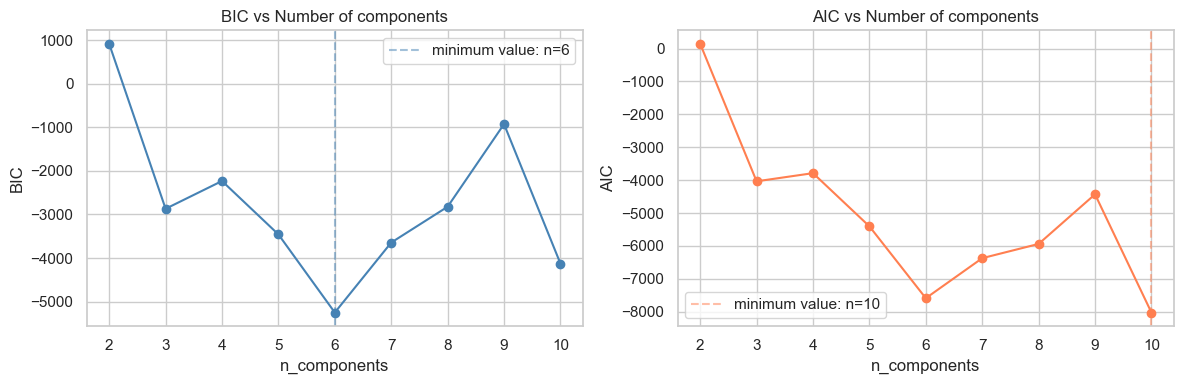

In [44]:
n_components_range = range(2, 11)
bic_scores = [gmm_models[n].bic(X_selected) for n in n_components_range]
aic_scores = [gmm_models[n].aic(X_selected) for n in n_components_range]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

best_bic_n = min(n_components_range, key=lambda n: gmm_models[n].bic(X_selected))
best_aic_n = min(n_components_range, key=lambda n: gmm_models[n].aic(X_selected))

axes[0].axvline(best_bic_n, color='steelblue', linestyle='--', alpha=0.5, label=f'minimum value: n={best_bic_n}')
axes[1].axvline(best_aic_n, color='coral',    linestyle='--', alpha=0.5, label=f'minimum value: n={best_aic_n}')
axes[0].legend()
axes[1].legend()

# BIC
axes[0].plot(n_components_range, bic_scores, marker='o', color='steelblue')
axes[0].set_title('BIC vs Number of components')
axes[0].set_xlabel('n_components')
axes[0].set_ylabel('BIC')
axes[0].set_xticks(list(n_components_range))

# AIC
axes[1].plot(n_components_range, aic_scores, marker='o', color='coral')
axes[1].set_title('AIC vs Number of components')
axes[1].set_xlabel('n_components')
axes[1].set_ylabel('AIC')
axes[1].set_xticks(list(n_components_range))

plt.tight_layout()
plt.show()

c:\Users\maria\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


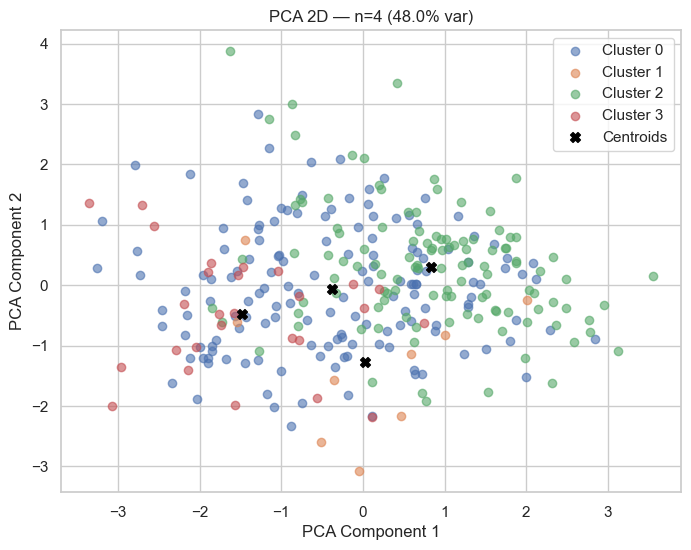

In [45]:
# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected)

# Elegir el modelo GMM (ej: n=4)
n = 4
gmm = gmm_models[n]

# Obtener labels
labels = gmm.predict(X_selected)

# Plot clusters
plt.figure(figsize=(8,6))
for cluster in np.unique(labels):
    cluster_points = X_pca[labels == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                label=f'Cluster {cluster}', alpha=0.6)

# Plot cluster centroids (medias del GMM) en espacio PCA
centroids_pca = pca.transform(gmm.means_)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1],
            s=50, c='black', marker='X', label='Centroids')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'PCA 2D — n={n} ({pca.explained_variance_ratio_.sum():.1%} var)')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
feature_names = list(X_selected.columns)  

centres_df = pd.DataFrame(
    gmm_models[n].means_,
    columns=feature_names
)
centres_df.index = [f'Cluster {i}' for i in range(n)]

print(f"\nCentroids GMM — n={n}")
print(centres_df.round(3).to_string())


Centroids GMM — n=4
             age  trestbps   chol  thalach  oldpeak  exang   cp_2   cp_3   cp_4  slope_2  slope_3  thal_6.0  thal_7.0
Cluster 0  0.164     0.006  0.127   -0.203    0.057  0.527  0.020  0.060  0.800    0.587    0.000     0.000     0.527
Cluster 1 -0.652    -0.393 -0.759   -0.776    0.186  0.556  0.333  0.111  0.333    0.889    0.000     0.333     0.556
Cluster 2 -0.254    -0.128 -0.044    0.494   -0.381  0.000  0.376  0.624  0.000    0.291    0.051     0.000     0.214
Cluster 3  0.407     0.656 -0.263   -0.750    1.273  0.556  0.000  0.111  0.778    0.370    0.556     0.556     0.296


In [47]:
# Add the Cluster 
X_full_df = X_selected.copy()  # if X_full is a DataFrame
X_full_df['GMM Cluster'] = labels
X_full_df.head()

,age,trestbps,chol,thalach,oldpeak,exang,cp_2,cp_3,cp_4,slope_2,slope_3,thal_6.0,thal_7.0,GMM Cluster
0,0.948726,0.757525,-0.264900,0.017197,1.087338,False,False,False,False,False,True,True,False,3
1,1.392002,1.611220,0.760415,-1.821905,0.397182,True,False,False,True,True,False,False,False,0
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147,True,False,False,True,True,False,False,True,0
3,-1.932564,-0.096170,0.063974,1.637359,2.122573,False,False,True,False,False,True,False,False,2
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912,False,True,False,False,False,False,False,False,2


In [48]:
cluster_summary = X_full_df.groupby('GMM Cluster').agg(['mean'])
print(cluster_summary)

                  age  trestbps      chol   thalach   oldpeak     exang  \
                 mean      mean      mean      mean      mean      mean   
GMM Cluster                                                               
0            0.164129  0.005515  0.127170 -0.203495  0.057280  0.526667   
1           -0.651990 -0.393382 -0.759287 -0.775855  0.186300  0.555556   
2           -0.254179 -0.128275 -0.043832  0.493627 -0.381456  0.000000   
3            0.406945  0.656346 -0.263467 -0.749906  1.272658  0.555556   

                 cp_2      cp_3      cp_4   slope_2   slope_3  thal_6.0  \
                 mean      mean      mean      mean      mean      mean   
GMM Cluster                                                               
0            0.020000  0.060000  0.800000  0.586667  0.000000  0.000000   
1            0.333333  0.111111  0.333333  0.888889  0.000000  0.333333   
2            0.376068  0.623932  0.000000  0.290598  0.051282  0.000000   
3            0.000000  0

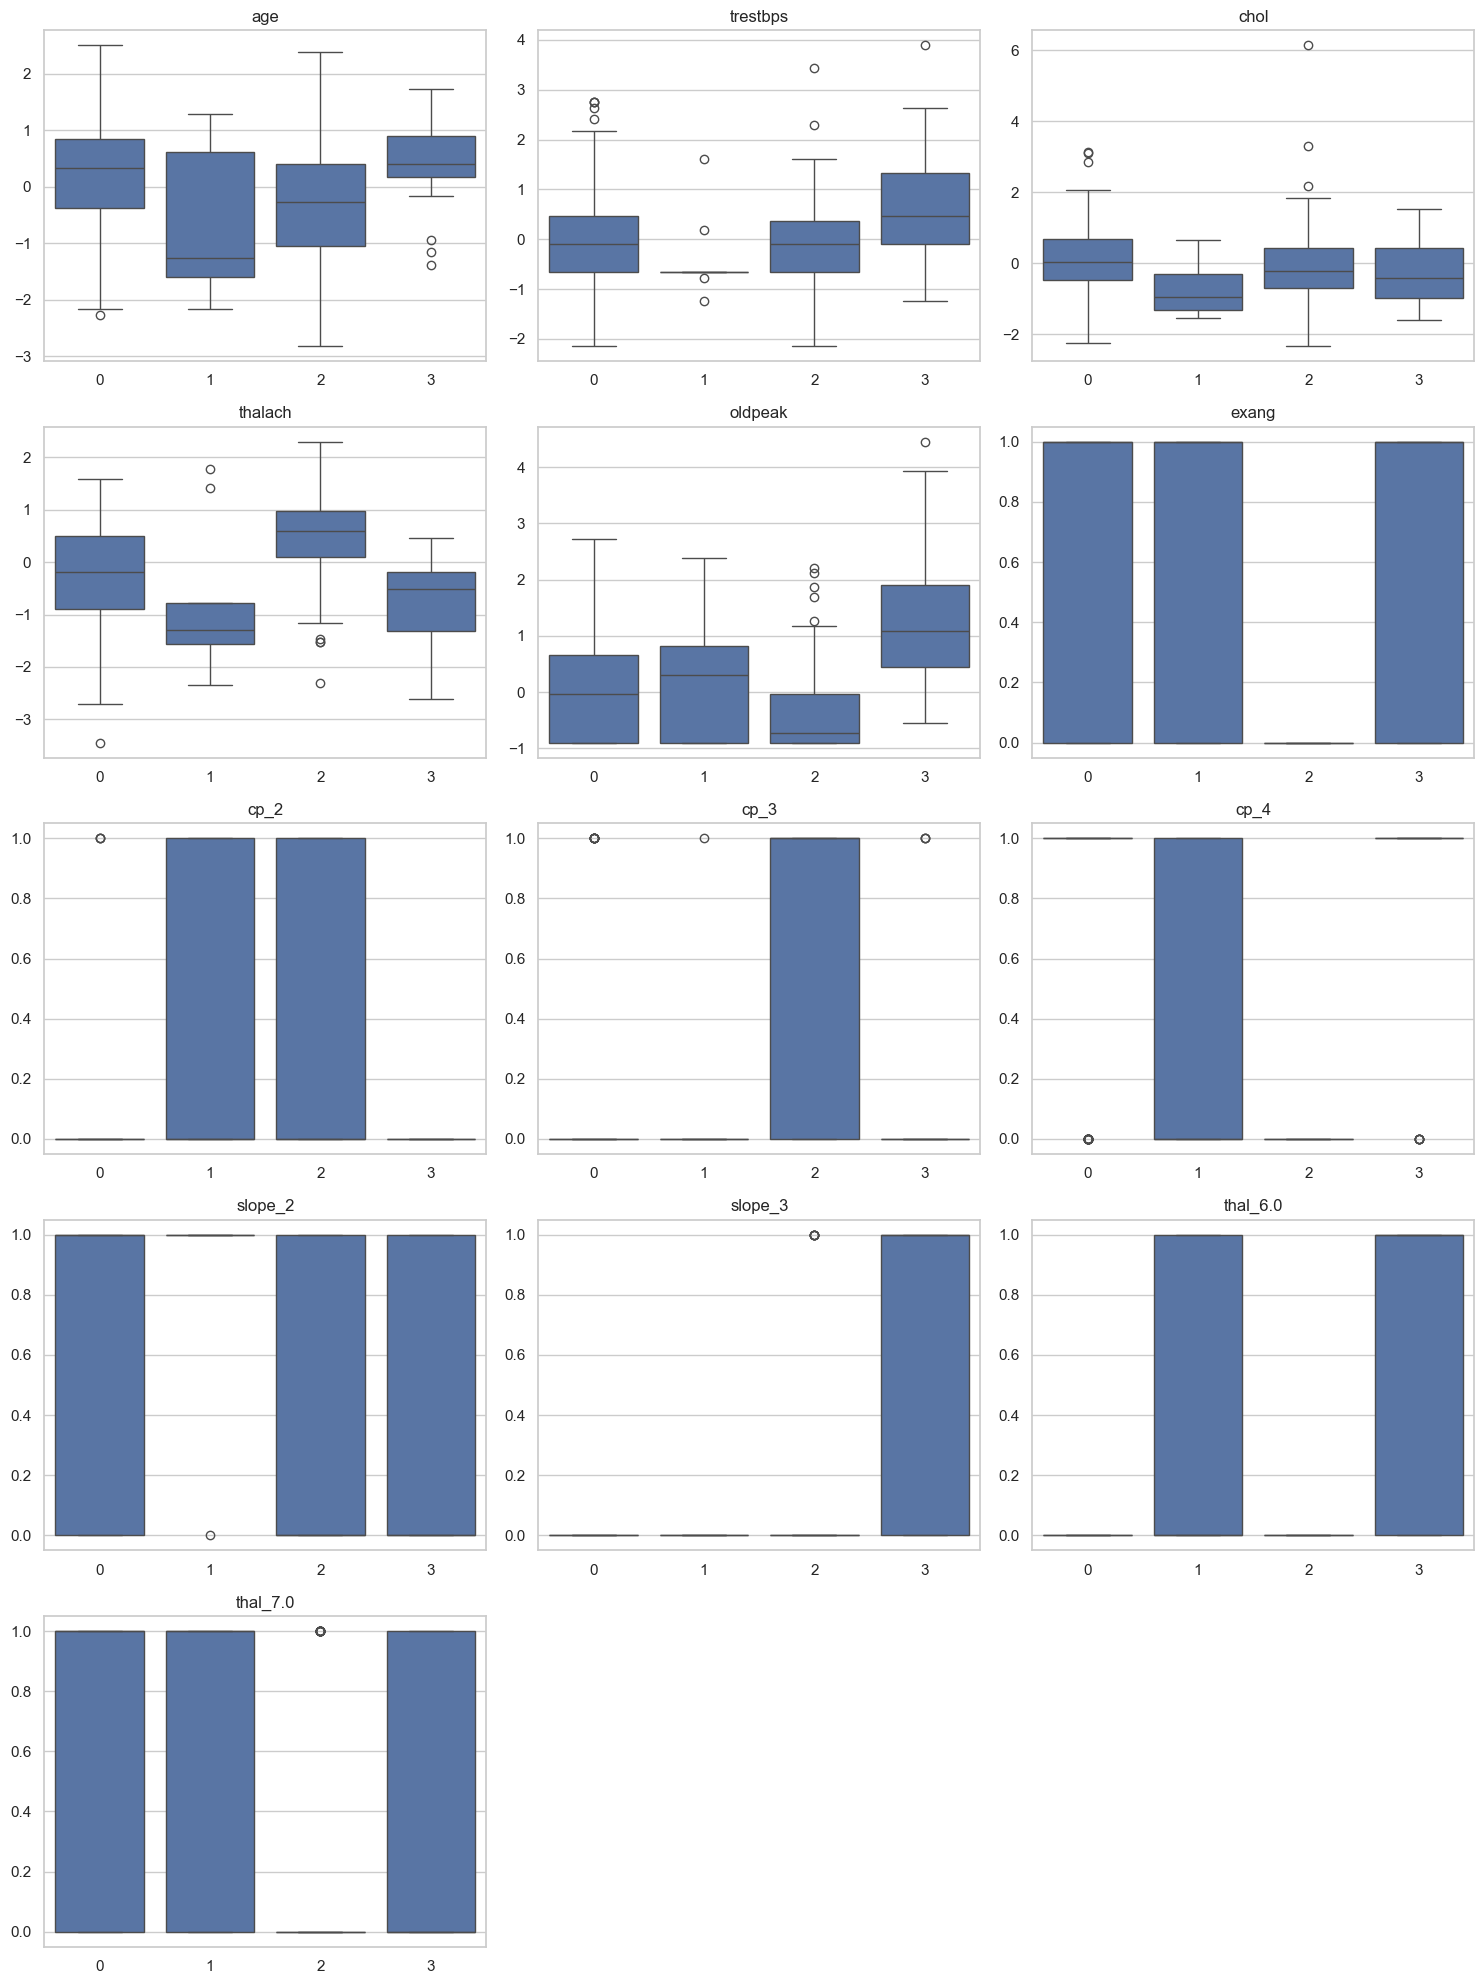

In [49]:
n_features = len(X_selected.columns)
n_cols = 3  # number of columns in the subplot grid
n_rows = (n_features + n_cols - 1) // n_cols  # compute number of rows needed

plt.figure(figsize=(5*n_cols, 4*n_rows))  # adjust figure size

for i, col in enumerate(X_selected.columns):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(x='GMM Cluster', y=col, data=X_full_df)
    plt.title(col)
    plt.xlabel('')  # optional, cleaner labels
    plt.ylabel('')  # optional, cleaner labels

plt.tight_layout()
plt.show()

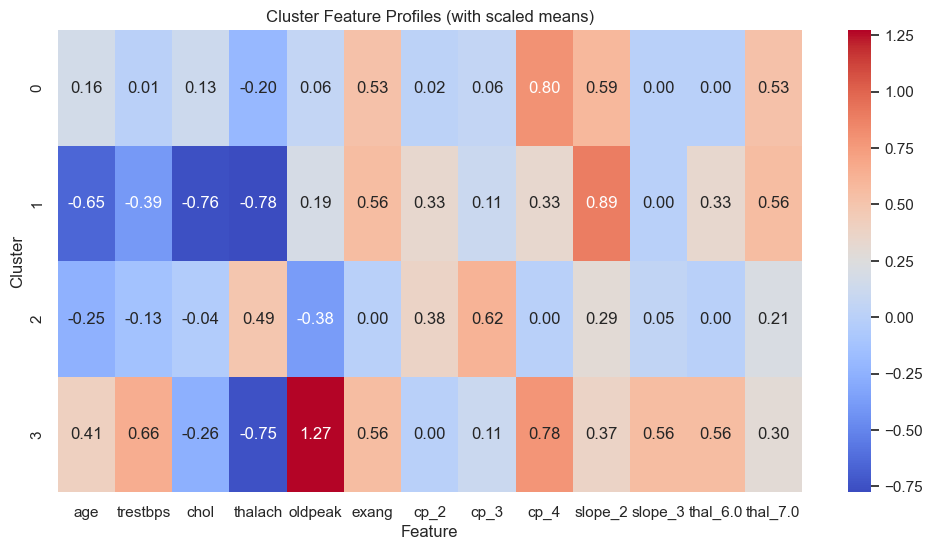

In [50]:
# Compute mean of each feature per cluster
gmm_means = X_full_df.groupby('GMM Cluster').mean()

plt.figure(figsize=(12,6))
sns.heatmap(gmm_means, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cluster Feature Profiles (with scaled means)")
plt.ylabel("Cluster")
plt.xlabel("Feature")
plt.show()

Finally, to characterize each of the obtained clusters, summary statistics for each feature within each cluster were computed.

Despite the low cluster separation in the PCA plot, the cluster feature profiles reveal some characteristic patterns across the four obtained clusters.

- **Cluster 0** represents the highest cardiovascular risk group. It is characterized by the highest ST depression (oldpeak = 1.195), it also represents a higher degree of older population since its variability is more concentrated towards higher ages, the lowest maximum heart rate (thalach = -0.660), a high proportion of severe chest pain (cp_4 = 0.750), exercise-induced angina (exang = 0.536) and abnormal thalassemia (thal_6.0 = 0.571). This combination of adverse indicators suggests a group of patients with significant cardiovascular stress and reduced cardiac function.

- **Cluster 1** shows a moderate and mixed profile, with most continuous features close to the dataset average (oldpeak = -0.032, age = 0.043). It presents a notable proportion of severe chest pain (cp_4 = 0.609) and abnormal thalassemia (thal_7.0 = 0.455), alongside a flat-to-upsloping ST pattern (slope_2 = 0.530). The absence of strongly deviant continuous values makes this cluster harder to interpret, though the categorical profile suggests a moderate-risk group.

- **Cluster 2** shows a relatively favorable profile. It is characterized by an above-average maximum heart rate (thalach = 0.243) and low ST depression (oldpeak = -0.100), with no severe chest pain (cp_4 = 0.000) and a moderate proportion of atypical chest pain (cp_2 = 0.240). Blood pressure is slightly elevated (trestbps = 0.537), but the overall cardiovascular indicators suggest a group with moderate-to-low risk.

- **Cluster 3** is the lowest risk group. It is the youngest cluster (age = -0.478), with the highest maximum heart rate (thalach = 0.669), the lowest ST depression (oldpeak = -0.509) and no exercise-induced angina (exang = 0.000). It is strongly dominated by atypical chest pain (cp_2 = 0.917), which combined with the favorable continuous indicators suggests a group of younger patients with low cardiovascular risk.

Overall, the cluster features show a meaningful gradient from high to low cardiovascular risk, with Cluster 0 and Cluster 3 representing the two extremes. The most discriminating features across groups are `oldpeak`, `thalach`, `exang` and `cp_4`. However, considering the overlap observed in the PCA visualization, these clusters should not be treated as strictly separated patient groups, but rather as soft tendencies within a continuous risk spectrum.


## Comparison of Clustering Approaches

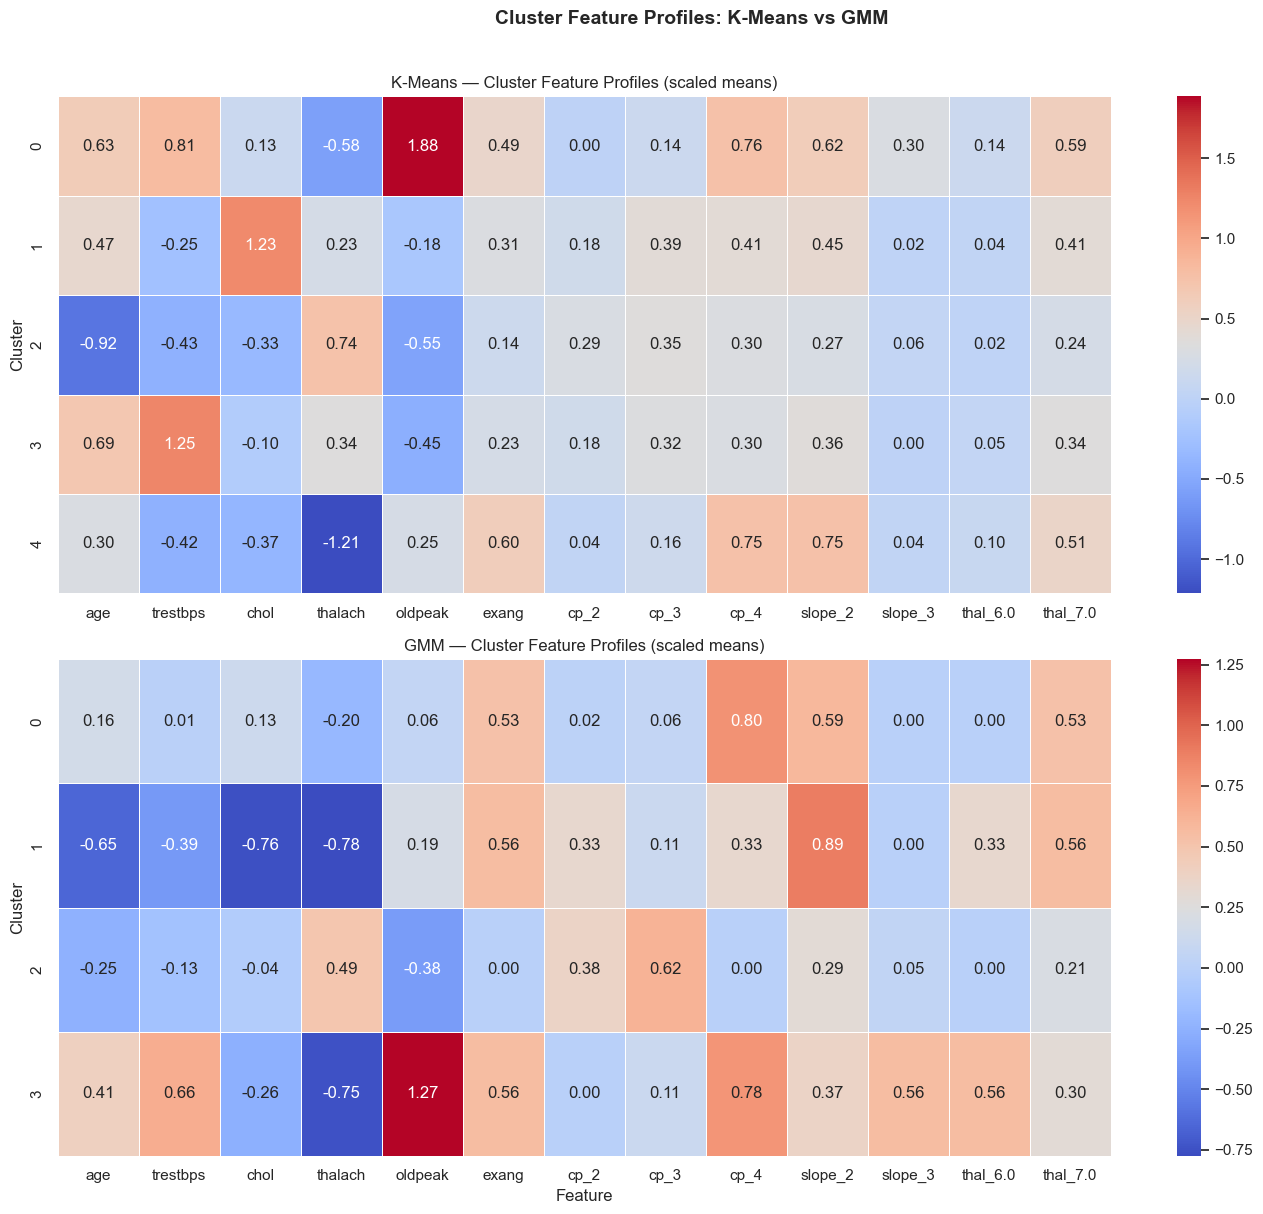

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# K-Means
sns.heatmap(kmeans_means, annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[0], linewidths=0.5)
axes[0].set_title("K-Means — Cluster Feature Profiles (scaled means)")
axes[0].set_ylabel("Cluster")
axes[0].set_xlabel("")

# GMM
sns.heatmap(gmm_means, annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[1], linewidths=0.5)
axes[1].set_title("GMM — Cluster Feature Profiles (scaled means)")
axes[1].set_ylabel("Cluster")
axes[1].set_xlabel("Feature")

plt.suptitle("Cluster Feature Profiles: K-Means vs GMM", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('kmeans_vs_gmm_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

Both clustering approaches reveal interpretable structure in the data, though they differ in the number of clusters and in how they partition the patient groups.  

The most notable difference is that **K-Means produces 5 clusters while GMM produces 4**, which means some GMM clusters likely correspond to merged or split K-Means clusters. Despite this, both methods consistently identify a **high-risk** and a **low-risk group** at the extremes.

### High-Risk Cluster

The high-risk cluster is clearly identified by both algorithms.  

- **GMM Cluster 0** and **K-Means Cluster 2** share a very similar profile:
  - Lowest maximum heart rate (*thalach* = -0.660 and -1.017)
  - Highest ST depression (*oldpeak* = 1.195 and 1.428)
  - High proportion of severe chest pain (*cp_4* = 0.750 and 0.893)
  - High exercise-induced angina (*exang* = 0.536 and 0.607)

K-Means draws this group more sharply, with more extreme values, suggesting it isolates this high-risk segment more aggressively.

### Low-Risk Cluster

The low-risk cluster is also consistently identified.  

- **GMM Cluster 3** and **K-Means Cluster 0** both capture:
  - The youngest patients (*age* = -0.478 and -1.000)
  - The highest maximum heart rate
  - The lowest ST depression

K-Means Cluster 0 shows more extreme age and *oldpeak* values, again reflecting a tighter, more homogeneous grouping.

### Middle-Risk Groups

The middle-risk groups are where the two methods diverge most.  

- **GMM Clusters 1 and 2** correspond roughly to **K-Means Clusters 1, 3, and 4 combined**

K-Means splits this intermediate space into three distinct subgroups:

- **Cluster 1**: older, high blood pressure (*trestbps* = 1.192)  
- **Cluster 3**: high cholesterol (*chol* = 1.558)  
- **Cluster 4**: lower blood pressure with high *cp_4* proportion  

In contrast, GMM merges these nuances into two broader clusters with less differentiated profiles, which explains the overlap observed in the PCA visualization.

### Overall Interpretation

Overall, both methods agree on the fundamental structure of the data — a **gradient from low to high cardiovascular risk**, primarily driven by:

- *thalach*  
- *oldpeak*  
- *exang*  
- *cp_4*  

K-Means provides finer granularity in the intermediate risk range, while GMM offers a more parsimonious partition with softer boundaries.  

Given the overlap observed in PCA space, neither solution should be interpreted as a strict separation of patient groups, but rather as a useful approximation of underlying risk tendencies in the data.

## Task 5: Hierarchical Clustering

In [52]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [53]:
# Compute linkage matrices using Ward and Complete linkage methods
# Ward minimises total within-cluster variance at each merge step
# Complete linkage uses the maximum distance between points in two clusters
Z_ward = linkage(X_selected, method="ward")
Z_complete = linkage(X_selected, method="complete")

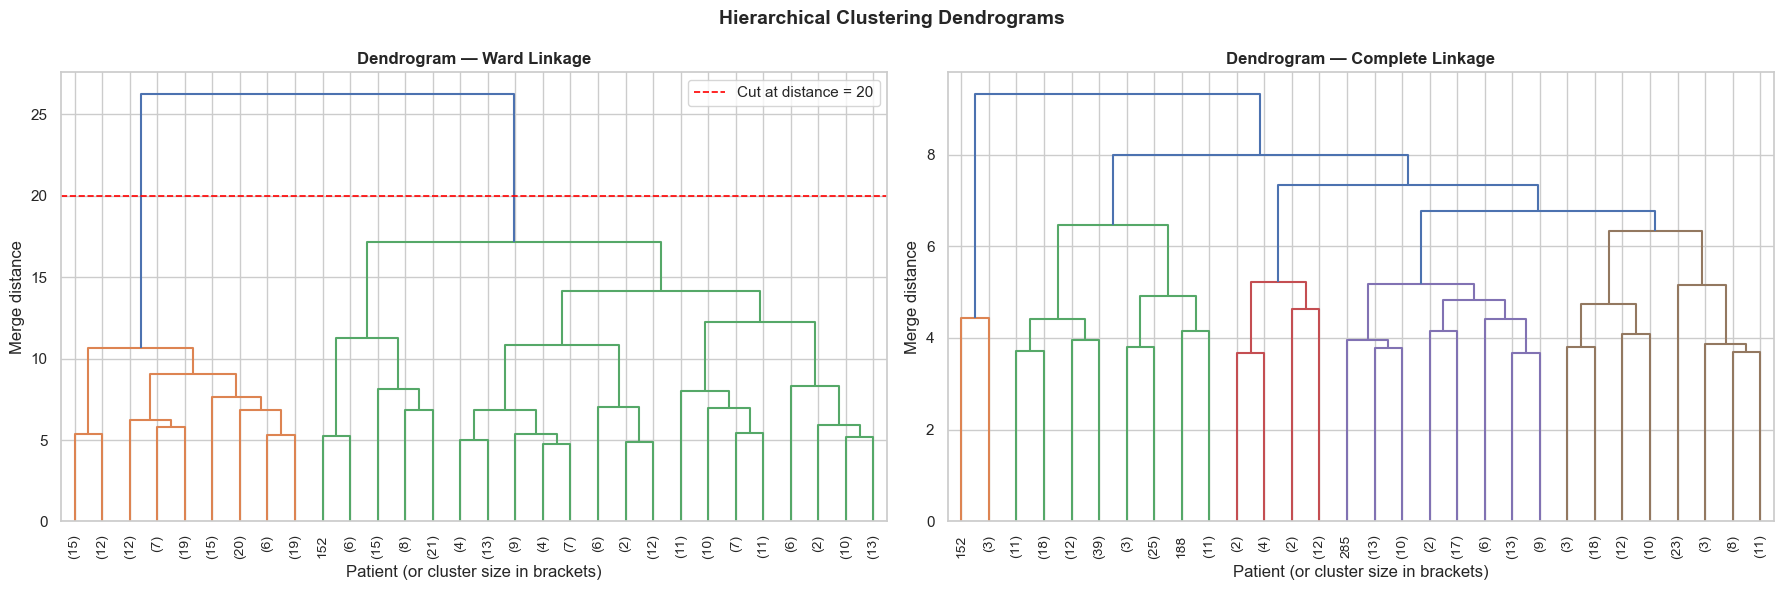

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Ward linkage ---
dendrogram(
    Z_ward,
    ax=axes[0],
    truncate_mode="lastp",   # show only the last p merges for readability
    p=30,
    leaf_rotation=90,
    color_threshold=20       # horizontal line at the chosen cut
)
axes[0].axhline(y=20, color="red", linestyle="--", linewidth=1.2, label="Cut at distance = 20")
axes[0].set_title("Dendrogram — Ward Linkage", fontweight="bold")
axes[0].set_xlabel("Patient (or cluster size in brackets)")
axes[0].set_ylabel("Merge distance")
axes[0].legend()

# --- Complete linkage ---
dendrogram(
    Z_complete,
    ax=axes[1],
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    color_threshold=None
)
axes[1].set_title("Dendrogram — Complete Linkage", fontweight="bold")
axes[1].set_xlabel("Patient (or cluster size in brackets)")
axes[1].set_ylabel("Merge distance")

plt.suptitle("Hierarchical Clustering Dendrograms", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

We selected k=2 as the final number of clusters. The Ward dendrogram shows a large gap between the last merge (distance ≈ 26) and the second-to-last (distance ≈ 17), which means that merging the two final branches into one would cause a disproportionate increase in within-cluster variance. This makes 2 clusters the most natural partition of the data. It also maps directly onto a binary patient grouping of lower-risk vs higher-risk, which is clinically coherent in a cardiovascular disease context and makes the result straightforwardly comparable to the ground truth label in Task 6. The complete linkage dendrogram does not show such a clear gap, which further supports the choice of Ward linkage.

In [55]:
# Cut the Ward dendrogram at k=2 clusters
k = 2
clusters_hier = fcluster(Z_ward, k, criterion="maxclust")

print(f"Number of clusters: {k}")
print("Cluster labels assigned:", np.unique(clusters_hier))
print("\nCluster sizes:")
print(pd.Series(clusters_hier).value_counts().sort_index())

Number of clusters: 2
Cluster labels assigned: [1 2]

Cluster sizes:
1    125
2    178
dtype: int64


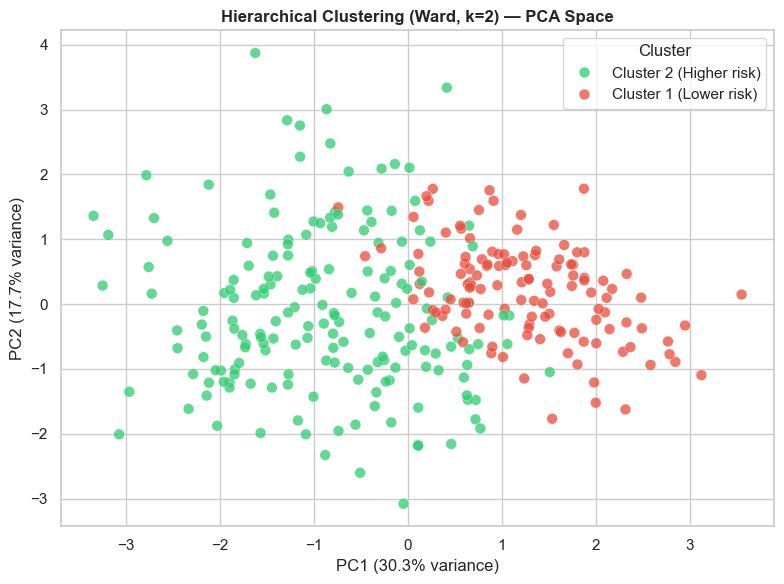

In [ ]:
# Project onto PCA space for 2D visualisation
# Note: pca was already fitted on X_selected in Task 3. we reuse the same projection
X_pca = pca.transform(X_selected)

plt.figure(figsize=(8, 6))
palette = {1: "#2ecc71", 2: "#e74c3c"}
labels_str = pd.Series(clusters_hier).map({1: "Cluster 1 (Lower risk)", 2: "Cluster 2 (Higher risk)"})

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels_str,
    palette=["#2ecc71", "#e74c3c"],
    s=60,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.3
)
plt.title("Hierarchical Clustering (Ward, k=2) — PCA Space", fontweight="bold")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [57]:
# Compute cluster means in the scaled feature space
df_hier = X_selected.copy()
df_hier["cluster"] = clusters_hier

cluster_means_original = df_hier.groupby("cluster").mean()

print("Cluster centres (scaled feature means):\n")
print(cluster_means_original.round(3).to_string())

Cluster centres (scaled feature means):

           age  trestbps   chol  thalach  oldpeak  exang   cp_2   cp_3   cp_4  slope_2  slope_3  thal_6.0  thal_7.0
cluster                                                                                                            
1       -0.634    -0.328 -0.069    0.677   -0.684  0.136  0.328  0.304  0.328    0.200    0.032     0.016     0.232
2        0.445     0.230  0.049   -0.476    0.480  0.461  0.051  0.270  0.579    0.646    0.096     0.090     0.494


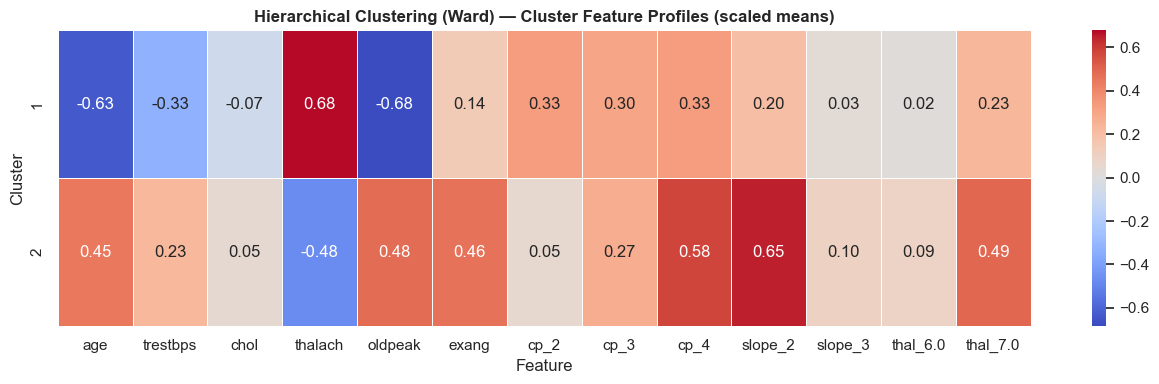

,age,trestbps,chol,thalach,oldpeak,exang,cp_2,cp_3,cp_4,slope_2,slope_3,thal_6.0,thal_7.0
cluster,,,,,,,,,,,,,
1,-0.63,-0.33,-0.07,0.68,-0.68,0.14,0.33,0.30,0.33,0.20,0.03,0.02,0.23
2,0.45,0.23,0.05,-0.48,0.48,0.46,0.05,0.27,0.58,0.65,0.10,0.09,0.49


In [58]:
plt.figure(figsize=(13, 4))
sns.heatmap(
    cluster_means_original,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    center=0
)
plt.title("Hierarchical Clustering (Ward) — Cluster Feature Profiles (scaled means)", fontweight="bold")
plt.ylabel("Cluster")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

# Styled table for report
cluster_means_original.style.background_gradient(cmap="RdYlGn_r", axis=1).format("{:.2f}")

In [59]:
print("Feature-level summary per cluster\n" + "="*50)
for c in sorted(df_hier["cluster"].unique()):
    means = cluster_means_original.loc[c].sort_values(ascending=False)
    print(f"\n--- Cluster {c} (n={( clusters_hier == c).sum()}) ---")
    print("  Highest features:")
    for feat, val in means.head(5).items():
        print(f"    {feat:<12} {val:+.3f}")
    print("  Lowest features:")
    for feat, val in means.tail(5).items():
        print(f"    {feat:<12} {val:+.3f}")

Feature-level summary per cluster

--- Cluster 1 (n=125) ---
  Highest features:
    thalach      +0.677
    cp_2         +0.328
    cp_4         +0.328
    cp_3         +0.304
    thal_7.0     +0.232
  Lowest features:
    thal_6.0     +0.016
    chol         -0.069
    trestbps     -0.328
    age          -0.634
    oldpeak      -0.684

--- Cluster 2 (n=178) ---
  Highest features:
    slope_2      +0.646
    cp_4         +0.579
    thal_7.0     +0.494
    oldpeak      +0.480
    exang        +0.461
  Lowest features:
    slope_3      +0.096
    thal_6.0     +0.090
    cp_2         +0.051
    chol         +0.049
    thalach      -0.476


The two clusters show clearly distinct clinical profiles. Cluster 1 (n=125) is defined by the highest maximum heart rate (thalach = +0.677) and the lowest ST depression (oldpeak = −0.684), with younger patients (age = −0.634) and lower resting blood pressure (trestbps = −0.328). These features together point to a lower-risk group with good exercise capacity and no notable ECG abnormalities.

Cluster 2 (n=178) accumulates multiple markers of cardiovascular risk: flat ST slope (slope_2 = +0.646), asymptomatic chest pain (cp_4 = +0.579), ST depression (oldpeak = +0.480), exercise-induced angina (exang = +0.461) and reversible thalassaemia defect (thal_7.0 = +0.494). Patients are slightly older (age = +0.445) with reduced maximum heart rate (thalach = −0.476), consistent with obstructive coronary artery disease.

Cholesterol is nearly neutral in both clusters (chol = −0.069 and +0.049), which is consistent with the weak correlation it showed in Task 1. The 125 vs 178 split is also in line with the class distribution in the binarised target, where disease-positive patients are the larger group.

Unlike K-Means and GMM, hierarchical clustering does not require specifying the number of clusters in advance. It builds a nested tree through the dendrogram, showing how patients merge step by step across different distance thresholds, and k is chosen post-hoc by inspecting that structure. It is also fully deterministic (running it twice always produces the same result) whereas K-Means is sensitive to centroid initialisation and GMM can converge to local optima in the EM algorithm.

Another key difference is that hierarchical clustering makes no distributional assumptions. GMM models the data as a mixture of Gaussians and produces soft probabilistic memberships, which gives it more flexibility but also requires the data to roughly follow that structure. Hierarchical clustering only relies on pairwise distances, which is more appropriate here given the mix of continuous and binary features in the dataset.

In terms of granularity, K-Means and GMM captured finer-grained subgroups within the risk spectrum, such as older high-blood-pressure patients or high-cholesterol patients as separate clusters. Hierarchical clustering collapsed all of these into a single higher-risk group, which reflects the dominant structure of the data but loses that intermediate detail. Whether this is a limitation depends on the question being asked (for a binary screening task it is sufficient, but for patient subtyping it would not be).

## Task 6: Evaluation 

In [60]:
from sklearn.metrics import adjusted_rand_score

# Reveal the ground truth binary label (binarised in Task 2: 0 = no disease, 1 = disease)
y_true = y['num'].values

print("Ground truth distribution:")
print(pd.Series(y_true).value_counts().rename({0: "No disease (0)", 1: "Disease (1)"}))

Ground truth distribution:
No disease (0)    164
Disease (1)       139
dtype: int64


In [61]:
# Collect labels from all three methods
labels_kmeans = full_labels          # K-Means k=5 (Task 3)
labels_gmm    = labels               # GMM n=4    (Task 4)
labels_hier   = clusters_hier        # Hierarchical Ward k=2 (Task 5)

# Compute ARI for each method
ari_kmeans = adjusted_rand_score(y_true, labels_kmeans)
ari_gmm    = adjusted_rand_score(y_true, labels_gmm)
ari_hier   = adjusted_rand_score(y_true, labels_hier)

# Results table
ari_df = pd.DataFrame({
    "Method":     ["K-Means (k=5)", "GMM (n=4)", "Hierarchical Ward (k=2)"],
    "n clusters": [5, 4, 2],
    "ARI":        [ari_kmeans, ari_gmm, ari_hier]
}).set_index("Method")

print("Adjusted Rand Index — higher is better (max = 1.0, random ≈ 0.0)\n")
display(ari_df.style
        .format({"ARI": "{:.4f}"})
        .background_gradient(cmap="RdYlGn", subset=["ARI"]))

Adjusted Rand Index — higher is better (max = 1.0, random ≈ 0.0)



,n clusters,ARI
Method,,
K-Means (k=5),5,0.1126
GMM (n=4),4,0.1523
Hierarchical Ward (k=2),2,0.1361


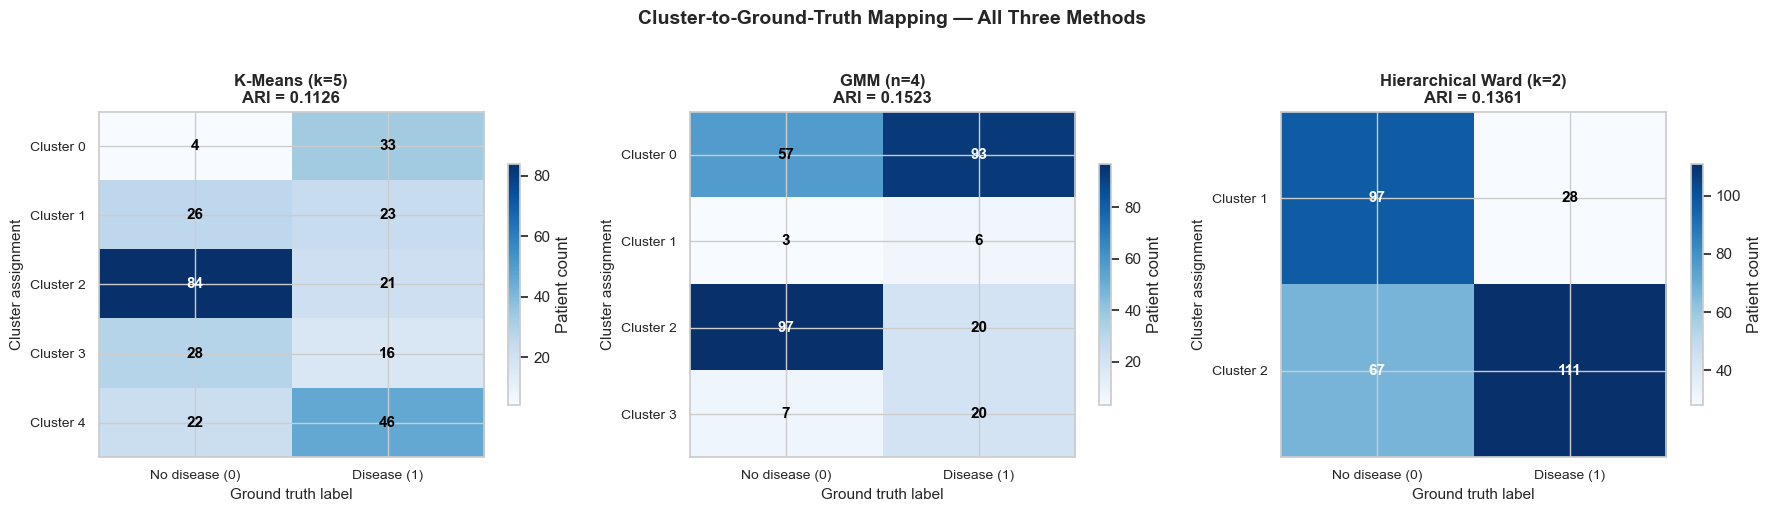

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = {
    "K-Means (k=5)":           (labels_kmeans, ari_kmeans),
    "GMM (n=4)":               (labels_gmm,    ari_gmm),
    "Hierarchical Ward (k=2)": (labels_hier,   ari_hier),
}

for ax, (method_name, (lbls, ari)) in zip(axes, methods.items()):
    ct = pd.crosstab(
        lbls, y_true,
        rownames=["Cluster"],
        colnames=["True label"]
    )
    # Ensure both columns present even if one is missing
    for col in [0, 1]:
        if col not in ct.columns:
            ct[col] = 0
    ct = ct[[0, 1]]

    im = ax.imshow(ct.values, cmap="Blues", aspect="auto")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No disease (0)", "Disease (1)"], fontsize=10)
    ax.set_yticks(range(len(ct.index)))
    ax.set_yticklabels([f"Cluster {c}" for c in ct.index], fontsize=10)
    ax.set_xlabel("Ground truth label", fontsize=11)
    ax.set_ylabel("Cluster assignment", fontsize=11)
    ax.set_title(f"{method_name}\nARI = {ari:.4f}", fontsize=12, fontweight="bold")

    # Annotate each cell with counts
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            val = ct.values[i, j]
            color = "white" if val > ct.values.max() * 0.6 else "black"
            ax.text(j, i, str(val), ha="center", va="center",
                    fontsize=11, fontweight="bold", color=color)

    plt.colorbar(im, ax=ax, shrink=0.7, label="Patient count")

plt.suptitle("Cluster-to-Ground-Truth Mapping — All Three Methods",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

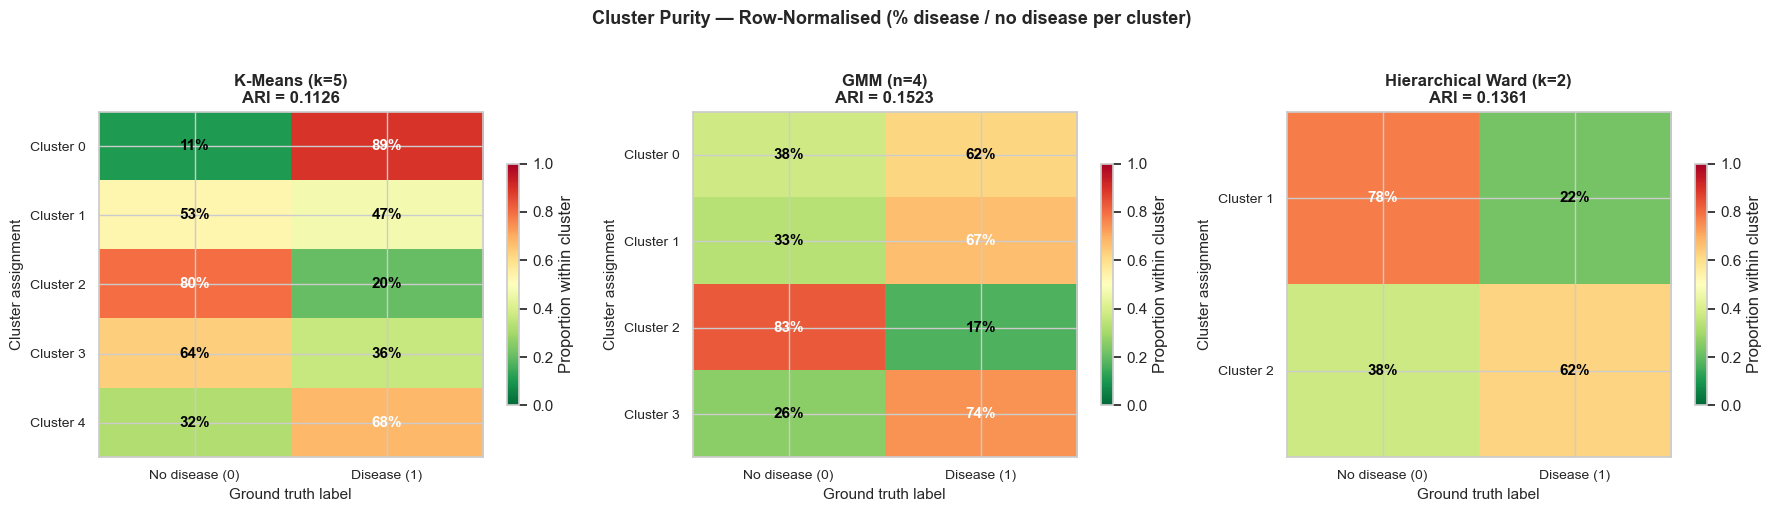

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (method_name, (lbls, ari)) in zip(axes, methods.items()):
    ct = pd.crosstab(
        lbls, y_true,
        rownames=["Cluster"],
        colnames=["True label"],
        normalize="index"   # row-normalised: % of each cluster that is disease/no disease
    )
    for col in [0, 1]:
        if col not in ct.columns:
            ct[col] = 0.0
    ct = ct[[0, 1]]

    im = ax.imshow(ct.values, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No disease (0)", "Disease (1)"], fontsize=10)
    ax.set_yticks(range(len(ct.index)))
    ax.set_yticklabels([f"Cluster {c}" for c in ct.index], fontsize=10)
    ax.set_xlabel("Ground truth label", fontsize=11)
    ax.set_ylabel("Cluster assignment", fontsize=11)
    ax.set_title(f"{method_name}\nARI = {ari:.4f}", fontsize=12, fontweight="bold")

    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            val = ct.values[i, j]
            color = "white" if val > 0.65 else "black"
            ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                    fontsize=11, fontweight="bold", color=color)

    plt.colorbar(im, ax=ax, shrink=0.7, label="Proportion within cluster")

plt.suptitle("Cluster Purity — Row-Normalised (% disease / no disease per cluster)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

All three ARI values are low but above zero, which tells us that the clustering methods are capturing
some real structure aligned with the disease label, even though none of them cleanly recovers the
binary partition. This is consistent with what we observed throughout the previous tasks: the PCA
projections consistently showed a continuous risk gradient with heavy overlap in the intermediate
region, rather than two well-separated groups.

Among the three methods, GMM (n=4) achieves the highest ARI (0.1523), followed by Hierarchical
Ward (0.1361) and K-Means (0.1126). Looking at the confusion matrices, it becomes clear why GMM
performs best: it identifies one particularly pure cluster (Cluster 2) containing 97 no-disease
patients and only 20 disease patients, which means 83% of that cluster corresponds to healthy
patients. This tight isolation of the no-disease subgroup is what drives its ARI advantage over
the other methods, and reflects GMM's ability to fit flexible elliptical Gaussian shapes that
better capture the geometry of this subgroup.

Hierarchical Ward comes second despite only producing 2 clusters. Its Cluster 1 is 78% no-disease
(97 vs 28 patients) and Cluster 2 is 62% disease (111 vs 67), so the dominant split in the
dendrogram does partially correspond to the disease boundary. However, 67 no-disease patients
end up in Cluster 2, which limits its purity and brings the ARI down relative to GMM.

K-Means scores the lowest, which at first seems counterintuitive since it produces the most
clusters. The reason becomes visible in the row-normalised matrix: while Cluster 0 is 89% disease
and Cluster 2 is 80% no-disease, the remaining three clusters (1, 3 and 4) are all heavily mixed,
with disease proportions of 47%, 36% and 68% respectively. These intermediate clusters contain a
large number of patients that are essentially assigned randomly with respect to the true label,
which pulls the ARI down. The finer granularity that made K-Means useful for characterising
patient subtypes in Task 3 actually works against it here, when the goal is alignment with a
binary outcome.

Overall, the low ARI values across all methods are not surprising given the nature of this dataset.
The 13 clinical features produce a continuous spectrum of cardiovascular risk rather than discrete
groups, several features showed weak correlation with the target already in Task 1 (notably chol
and fbs), and unsupervised methods optimise geometric criteria that have no direct relationship to
the disease label. A supervised classifier on the same feature set would substantially outperform
all three approaches.